# ANADIA

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [36]:
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.datasources import codab, anadia, floodscan, hydrosheds, abn
from src.utils import shift_to_floodseason
from src.constants import *

In [3]:
adm3 = codab.load_codab(admin_level=3, aoi_only=True)
adm2 = codab.load_codab(admin_level=2, aoi_only=True)
adm1 = codab.load_codab(admin_level=1, aoi_only=True)

In [4]:
river = hydrosheds.load_niger_river()
river_aoi = gpd.sjoin(river, adm3, how="inner", predicate="intersects")

(-0.05552903579999999, 4.8236206858, 11.462306522549298, 15.912396359783367)

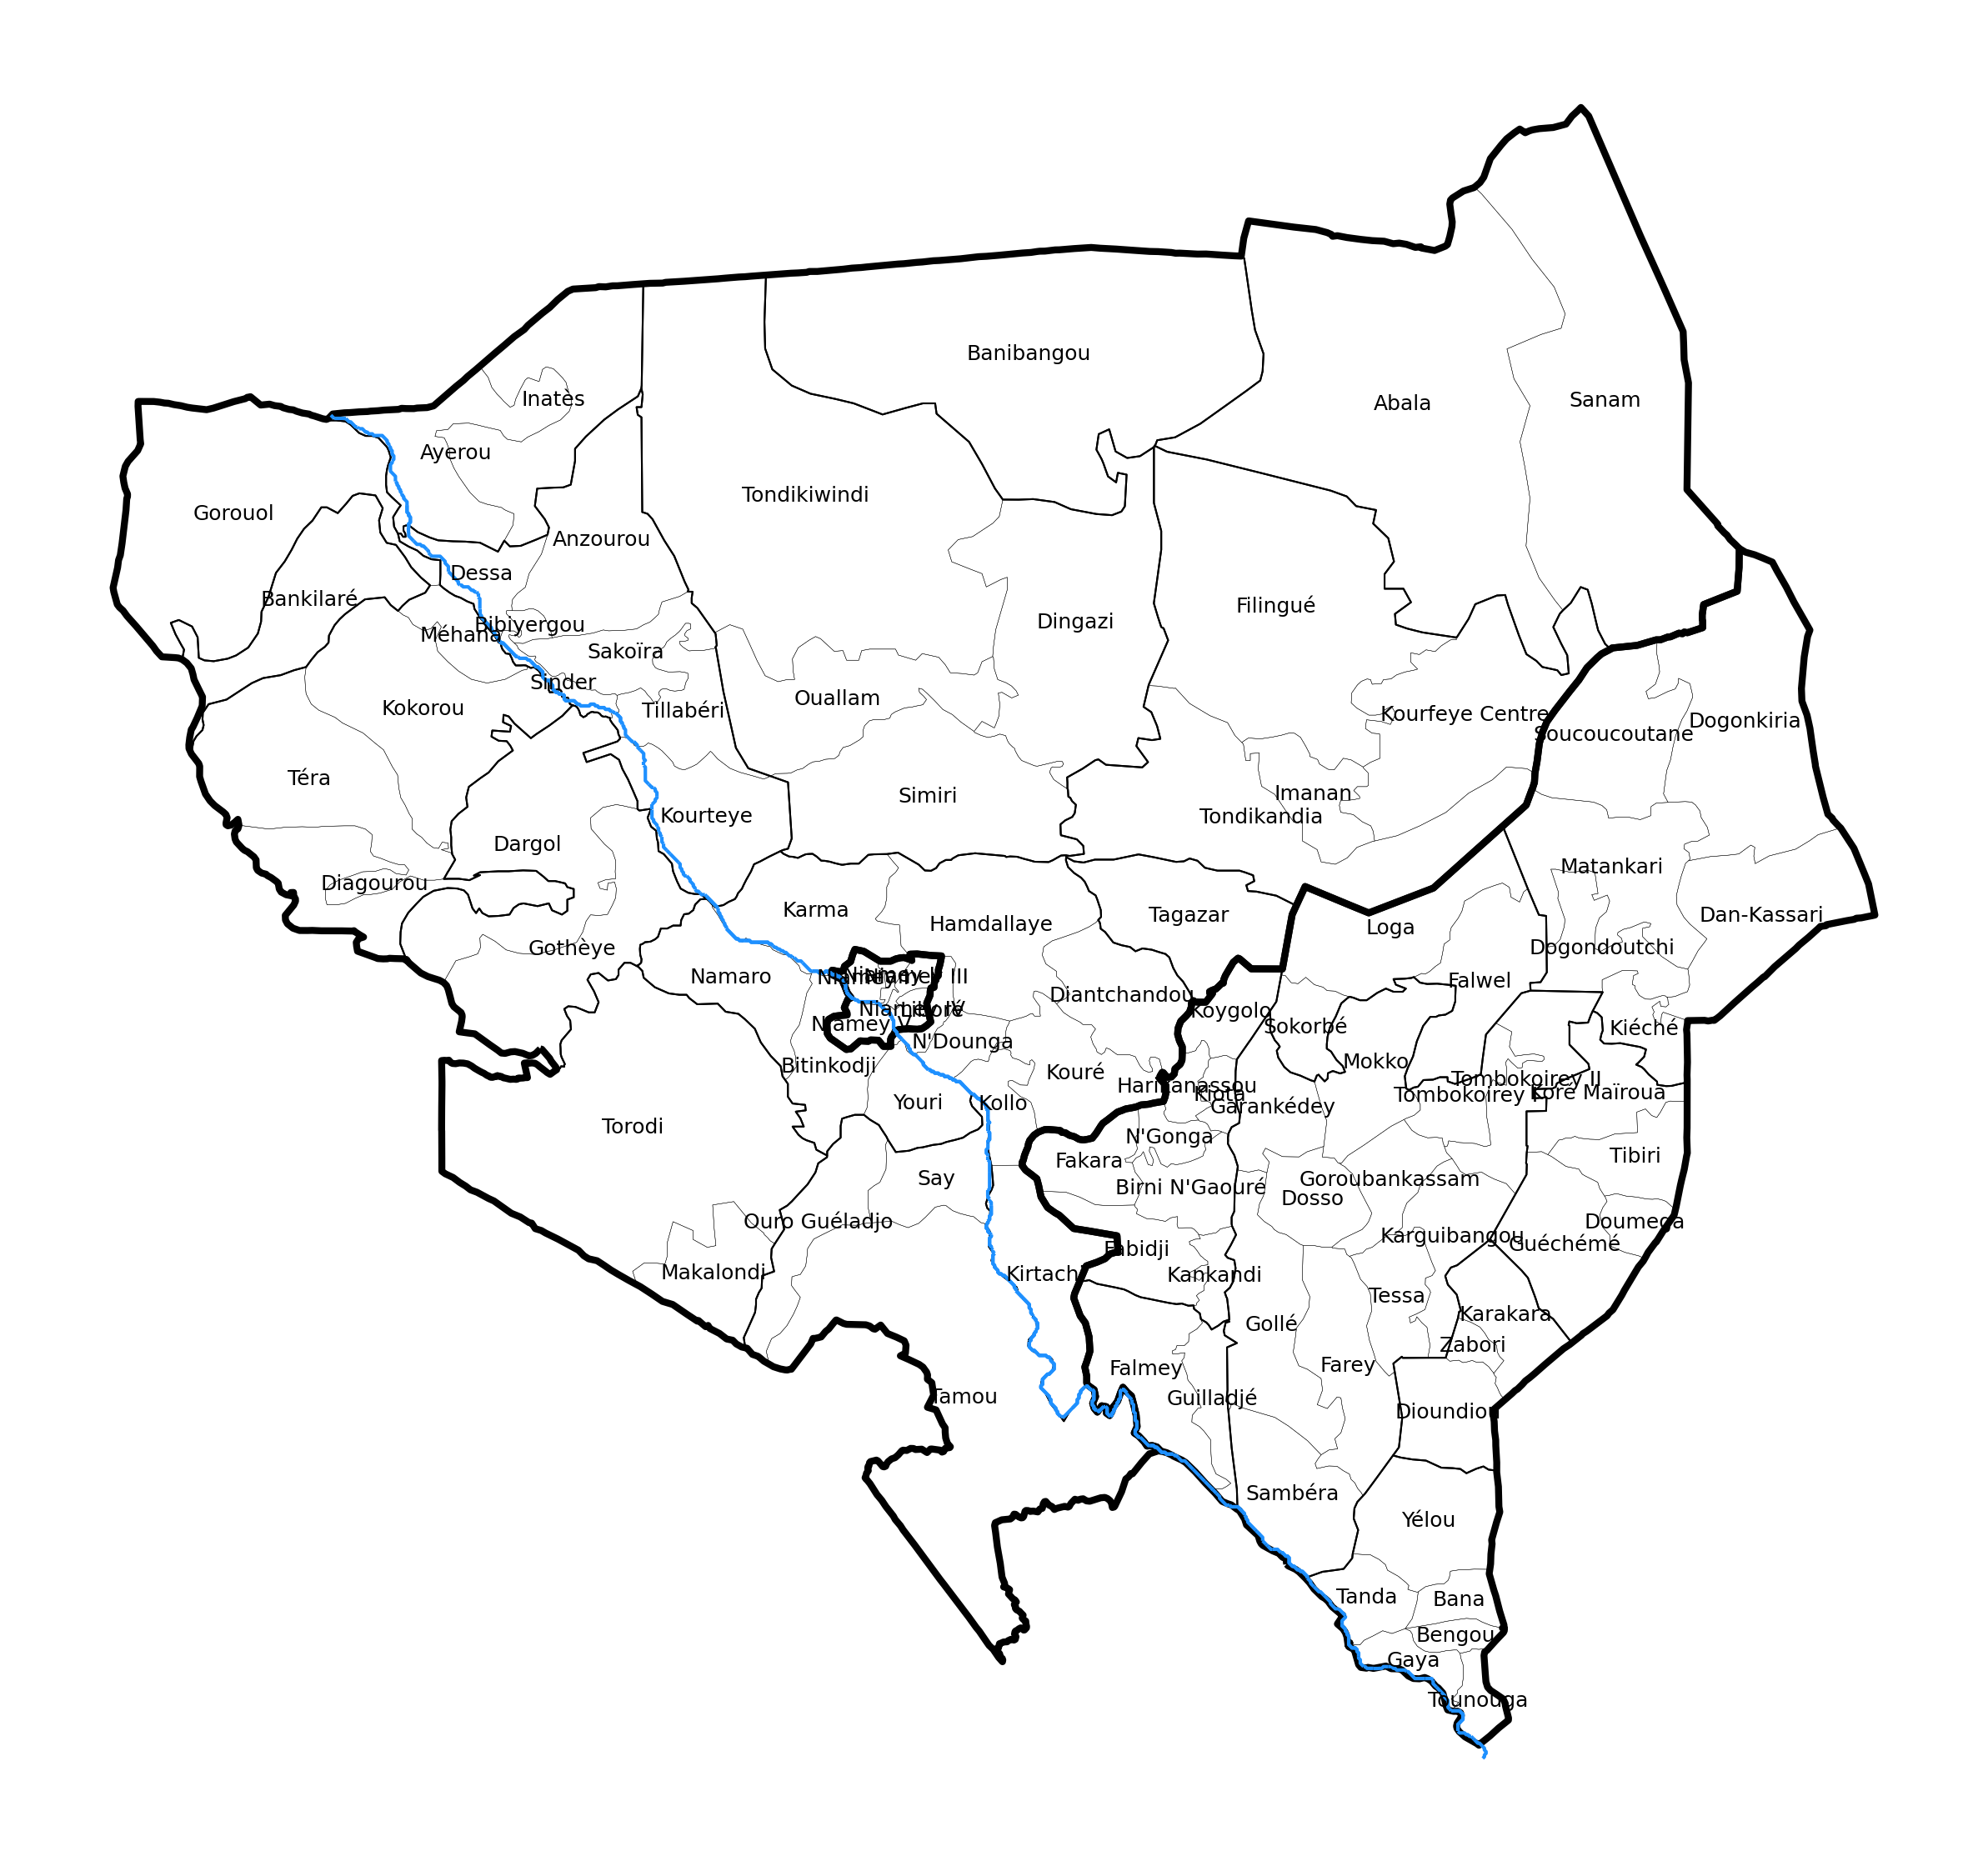

In [5]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
adm3.boundary.plot(ax=ax, linewidth=0.1, color="k")
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
adm1.boundary.plot(ax=ax, color="k", linewidth=2)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
for index, row in adm3.iterrows():
    centroid = row["geometry"].centroid
    ax.annotate(
        row["ADM3_FR"],
        xy=(centroid.x, centroid.y),
        xytext=(0, 0),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=6,
    )

ax.axis("off")

In [6]:
impact = anadia.load_processed_anadia()
impact = impact.rename(columns={"Maisons détruites": "destroyed"})

In [74]:
impact[impact["Communes"] == "SINDER"]

,idEvent,Régions,Départments,Communes,Type Commune,Localités,Code Renaloc,Type localité,Source localité,Ville,...,Digues détruites,Clases d'école détruites,Magasins détruits,Moulins à grain détruits,Postes radio détruits,Centres de santé détruits,date,match_adm3,rowcacode3,ADM3_PCODE
1683,217.0,TILLABERI,TILLABERI,SINDER,RURALE,DJONTE LASSIA,61206026,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1684,224.0,TILLABERI,TILLABERI,SINDER,RURALE,SONSONIBON,61206086,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1685,218.0,TILLABERI,TILLABERI,SINDER,RURALE,FALA,61206031,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1686,223.0,TILLABERI,TILLABERI,SINDER,RURALE,SINDER KANDADJI,61206082,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1687,226.0,TILLABERI,TILLABERI,SINDER,RURALE,WISSILI,61206113,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1688,215.0,TILLABERI,TILLABERI,SINDER,RURALE,ABADA,61206001,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1689,216.0,TILLABERI,TILLABERI,SINDER,RURALE,DARBANI,61206018,NON DISPONIBLE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1690,220.0,TILLABERI,TILLABERI,SINDER,RURALE,NORANDE,61206068,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1691,219.0,TILLABERI,TILLABERI,SINDER,RURALE,KOMA,61206057,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006
1692,221.0,TILLABERI,TILLABERI,SINDER,RURALE,SAWANI,61206073,VILLAGE,RENALOC,NON DISPONIBLE,...,0.0,0.0,0.0,0.0,0.0,0.0,2010-09-01,sinder,NER006012006,NE006012006


In [7]:
impact["date"].dt.year.value_counts()

date
2013    356
2020    267
2017    175
2018    139
2015    136
2012    135
2019    119
2010    114
2014    102
2007     94
2016     82
2006     71
2011     70
2009     45
2008     39
1999     10
2005     10
2004      8
2003      6
2002      6
1998      4
2000      4
2001      1
Name: count, dtype: int64

In [8]:
years = range(2006, 2021)

In [9]:
level = abn.load_abn_niamey().reset_index()
level = level.rename(columns={"Date": "time", "Water Level (cm)": "level"})
level = shift_to_floodseason(level, date_col="time")
# drop duplicates due to leapyears (just on Jan 1)
level = level[~level.duplicated(subset=["dayofseason", "seasonyear"])]
# keep only full seasons
level = level[level["seasonyear"].isin(range(2005, 2022))]
# take first chunk of season
level_first = level[level["dayofseason"] < 153]
level_max = (
    level_first.groupby("seasonyear")["level"]
    .max()
    .reset_index()
    .rename(columns={"seasonyear": "year"})
)
level_max["activate"] = level_max["level"] > 580

level_max_years = level_max[level_max["year"].isin(years)]

In [10]:
level_max_years

,year,level,activate
1,2006,512.000,False
2,2007,465.000,False
3,2008,470.000,False
4,2009,491.667,False
5,2010,565.000,False
6,2011,462.667,False
7,2012,616.667,True
8,2013,611.750,True
9,2014,459.000,False
10,2015,579.667,False


In [11]:
19 / 7

2.7142857142857144

In [12]:
7 / 19

0.3684210526315789

<Axes: xlabel='year'>

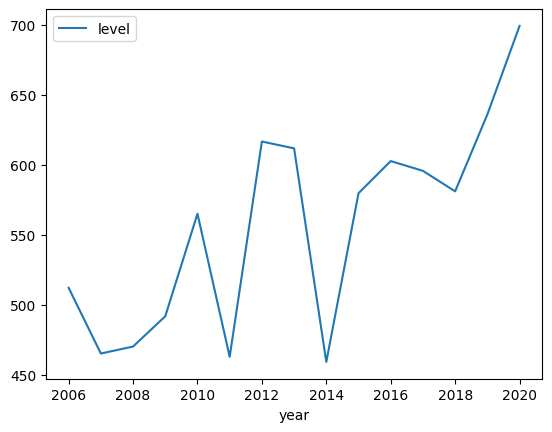

In [13]:
level_max_years.plot(x="year", y="level")

In [14]:
exp = floodscan.load_daily_exposure()

In [15]:
rolls = [1, 3, 5, 7, 9, 11]
for roll in rolls:
    exp[f"fs_roll{roll}"] = (
        exp.groupby("ADM3_PCODE")["total_exposed"]
        .transform(lambda x: x.rolling(window=roll, min_periods=roll).mean())
        .shift(-np.floor(roll / 2).astype(int))
    )

In [16]:
exp_max = (
    exp.groupby([exp["time"].dt.year, "ADM3_PCODE"])
    .max()
    .drop(columns="time")
    .reset_index()
    .rename(columns={"time": "year"})
)
exp_max_years = exp_max[exp_max["year"].isin(years)]
exp_max_years

,year,ADM3_PCODE,total_exposed,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11
744,2006,NE003001001,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
745,2006,NE003001002,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
746,2006,NE003001003,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
747,2006,NE003001004,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
748,2006,NE003001005,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
2134,2020,NE008001001,1795,1795.0,726.666667,436.0,311.428571,242.222222,198.181818
2135,2020,NE008001002,227,227.0,129.000000,77.4,55.285714,43.000000,35.181818
2136,2020,NE008001003,191,191.0,116.333333,69.8,49.857143,38.777778,31.727273
2137,2020,NE008001004,697,697.0,354.666667,212.8,152.000000,118.222222,96.727273


In [17]:
exp_max_years_mean

NameError: name 'exp_max_years_mean' is not defined

In [18]:
impact_sum = (
    impact.groupby([impact["date"].dt.year, impact["ADM3_PCODE"]])["destroyed"]
    .sum()
    .reset_index()
    .rename(columns={"date": "year"})
)
impact_sum_years = impact_sum[impact_sum["year"].isin(years)]

In [42]:
SINDER in impact_sum_years["ADM3_PCODE"].unique()

True

In [193]:
impact_sum_years["year"].nunique()

15

<Axes: xlabel='year'>

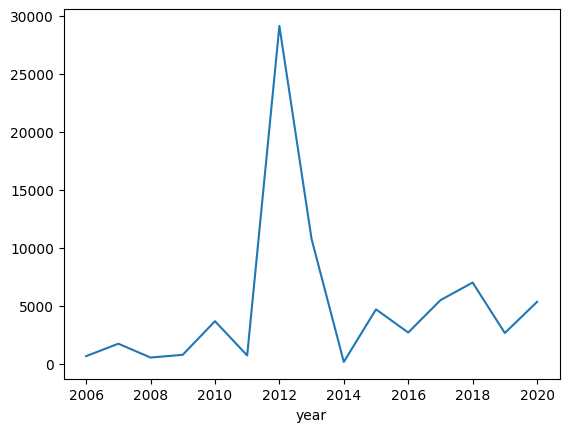

In [88]:
impact_sum_years.groupby("year").sum()["destroyed"].plot()

In [46]:
compare = impact_sum_years.merge(
    exp_max_years, on=["year", "ADM3_PCODE"], how="right"
)
compare = compare.merge(level_max_years, on="year")
compare["destroyed"] = compare["destroyed"].fillna(0).astype(int)
compare

,year,ADM3_PCODE,destroyed,total_exposed,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11,level,activate
0,2006,NE003001001,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,512.000,False
1,2006,NE003001002,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,512.000,False
2,2006,NE003001003,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,512.000,False
3,2006,NE003001004,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,512.000,False
4,2006,NE003001005,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,512.000,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1390,2020,NE008001001,0,1795,1795.0,726.666667,436.0,311.428571,242.222222,198.181818,699.333,True
1391,2020,NE008001002,0,227,227.0,129.000000,77.4,55.285714,43.000000,35.181818,699.333,True
1392,2020,NE008001003,0,191,191.0,116.333333,69.8,49.857143,38.777778,31.727273,699.333,True
1393,2020,NE008001004,0,697,697.0,354.666667,212.8,152.000000,118.222222,96.727273,699.333,True


In [48]:
SINDER in compare["ADM3_PCODE"].unique()

True

In [49]:
def is_worst_third(group):
    q = group["destroyed"].quantile(q=2 / 3)
    group["worst_third"] = group["destroyed"] > q
    # print(group)
    return group.drop(columns="ADM3_PCODE")


compare = (
    compare.groupby("ADM3_PCODE")
    .apply(is_worst_third)
    .reset_index()
    .drop(columns="level_1")
)
compare["TP"] = compare["activate"] & compare["worst_third"]
compare["FP"] = compare["activate"] & ~compare["worst_third"]
compare["TN"] = ~compare["activate"] & ~compare["worst_third"]
compare["FN"] = ~compare["activate"] & compare["worst_third"]
compare

,ADM3_PCODE,year,destroyed,total_exposed,fs_roll1,fs_roll3,fs_roll5,fs_roll7,fs_roll9,fs_roll11,level,activate,worst_third,TP,FP,TN,FN
0,NE003001001,2006,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,512.000,False,False,False,False,True,False
1,NE003001001,2007,0,6806,6806.0,2268.666667,1361.2,972.285714,756.222222,618.727273,465.000,False,False,False,False,True,False
2,NE003001001,2008,195,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,470.000,False,True,False,False,False,True
3,NE003001001,2009,0,98,98.0,68.000000,43.2,30.857143,24.000000,19.636364,491.667,False,False,False,False,True,False
4,NE003001001,2010,35,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,565.000,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1390,NE008001005,2016,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,602.667,True,False,False,True,False,False
1391,NE008001005,2017,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,595.667,True,False,False,True,False,False
1392,NE008001005,2018,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,581.000,True,False,False,True,False,False
1393,NE008001005,2019,0,0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,636.000,True,False,False,True,False,False


In [50]:
SINDER in compare["ADM3_PCODE"].unique()

True

In [52]:
impact_sum_years_mean = (
    compare.groupby("ADM3_PCODE")
    .mean()[["destroyed", "fs_roll3"]]
    .reset_index()
)

In [53]:
SINDER in impact_sum_years_mean["ADM3_PCODE"].unique()

True

In [54]:
dicts = []
for pcode, group in compare.groupby("ADM3_PCODE"):
    corr = group.drop(columns=["year", "ADM3_PCODE", "total_exposed"]).corr()[
        "destroyed"
    ]
    P = group["worst_third"].sum()
    TP = group["TP"].sum()
    TPR = TP / P
    dicts.append(
        {
            "ADM3_PCODE": pcode,
            "exp_corr": corr["fs_roll3"],
            "level_corr": corr["level"],
            "TPR": TPR,
        }
    )


all_corr = pd.DataFrame(dicts)
all_corr = all_corr.merge(impact_sum_years_mean, on="ADM3_PCODE")
all_corr = all_corr.sort_values("destroyed", ascending=False)

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848/1373274739.py:8: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / P
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848/1373274739.py:8: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / P
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848/1373274739.py:8: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / P
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848/1373274739.py:8: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / P
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848/1373274739.py:8: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / P
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848/1373274739.py:8: RuntimeWarning: invalid value encountered in scalar divide
  TPR = TP / P
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_82848

In [56]:
SINDER in all_corr["ADM3_PCODE"].unique()

True

<Axes: xlabel='destroyed'>

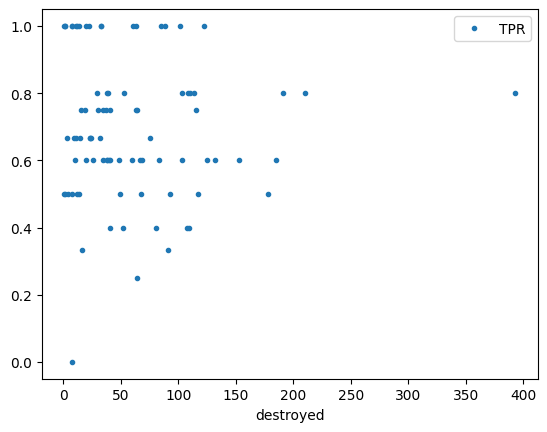

In [24]:
all_corr.plot(x="destroyed", y="TPR", linestyle="", marker=".")

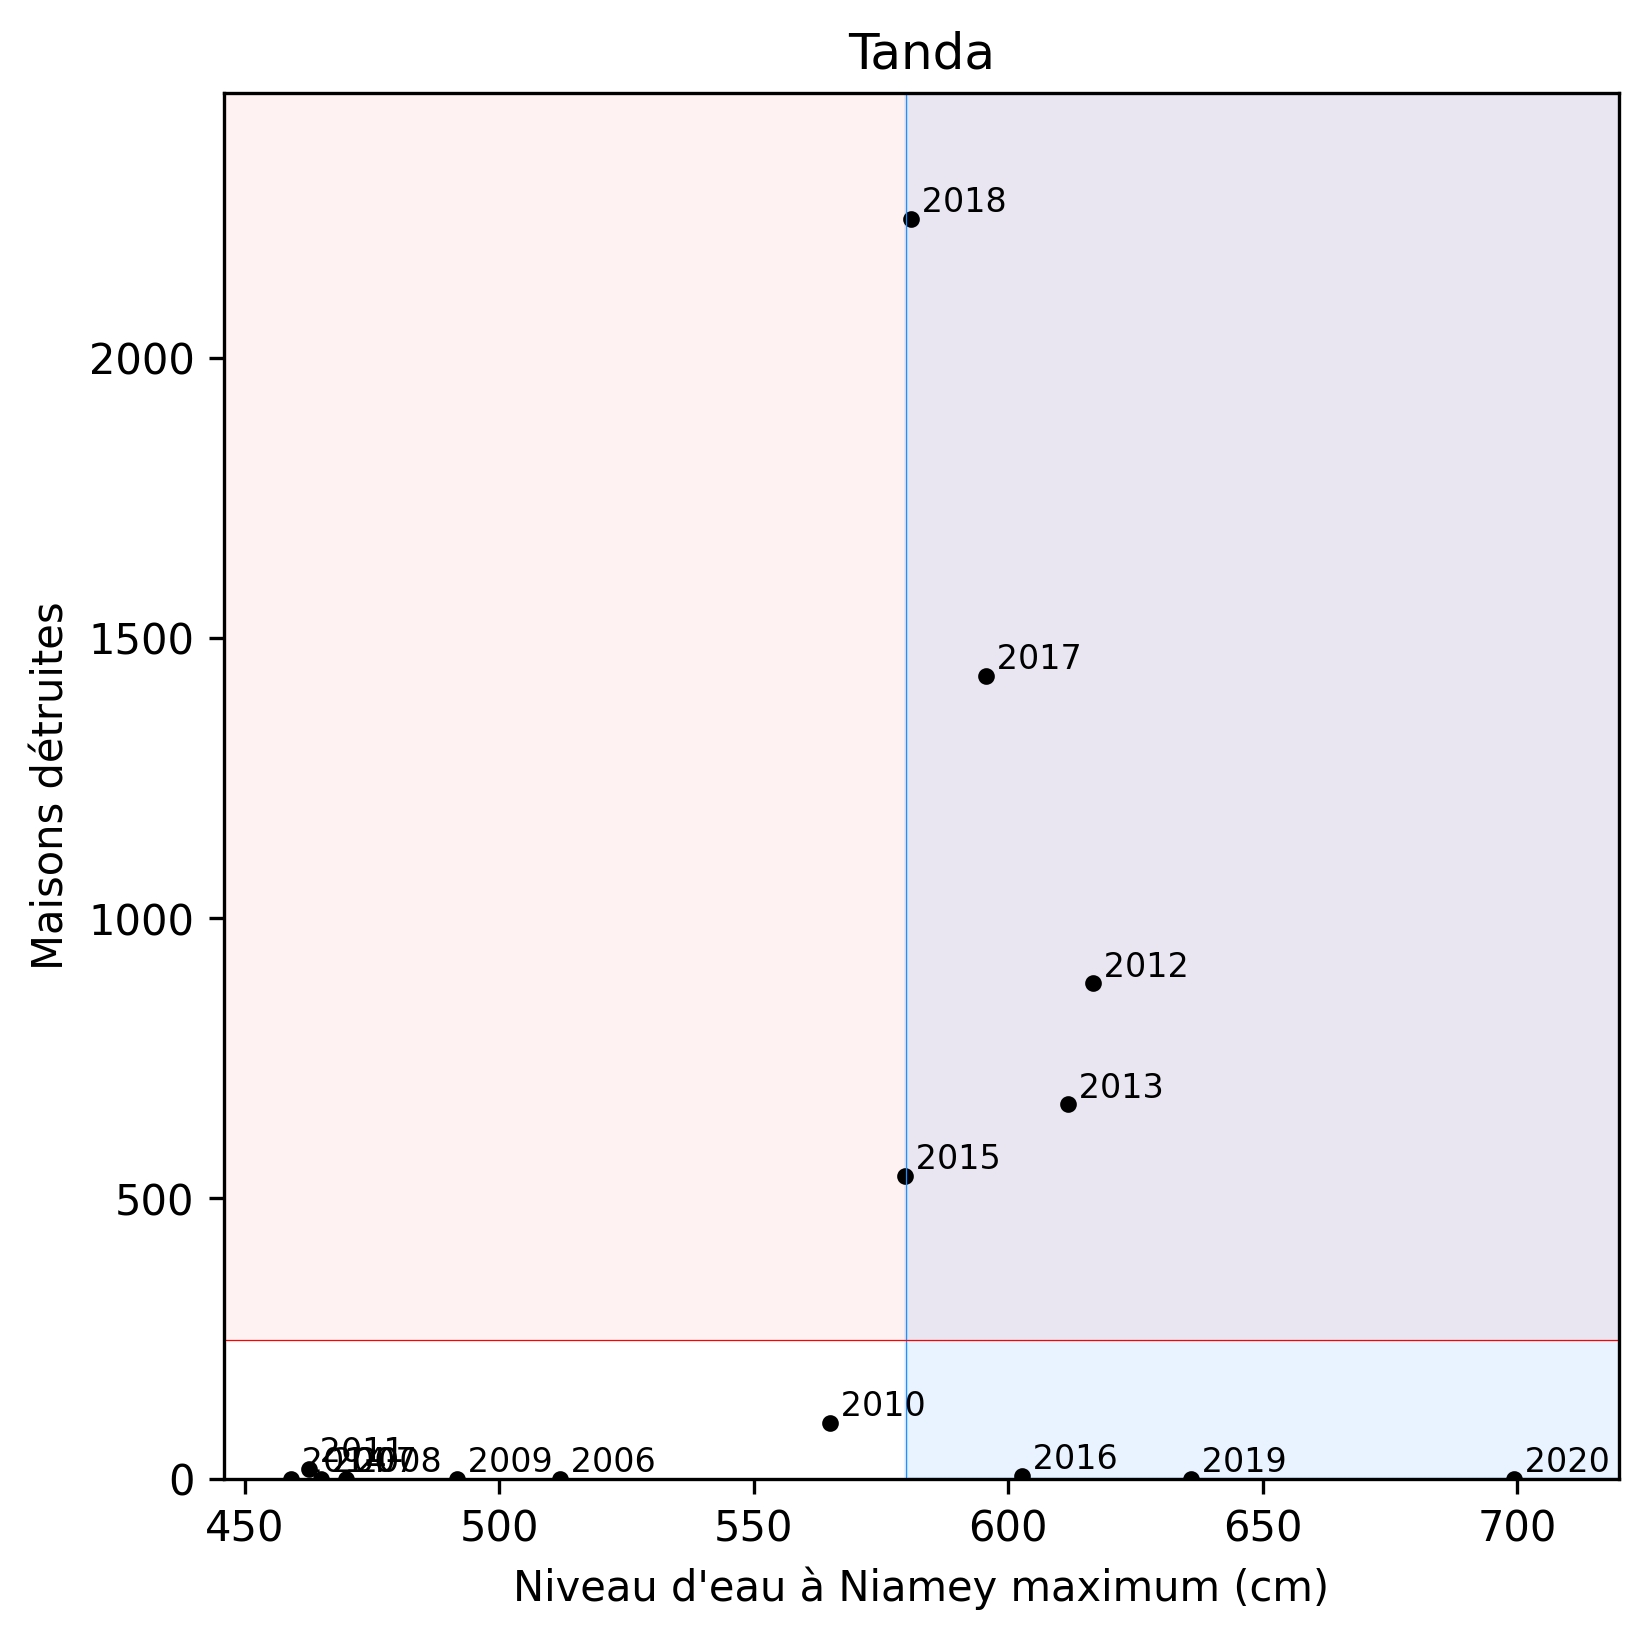

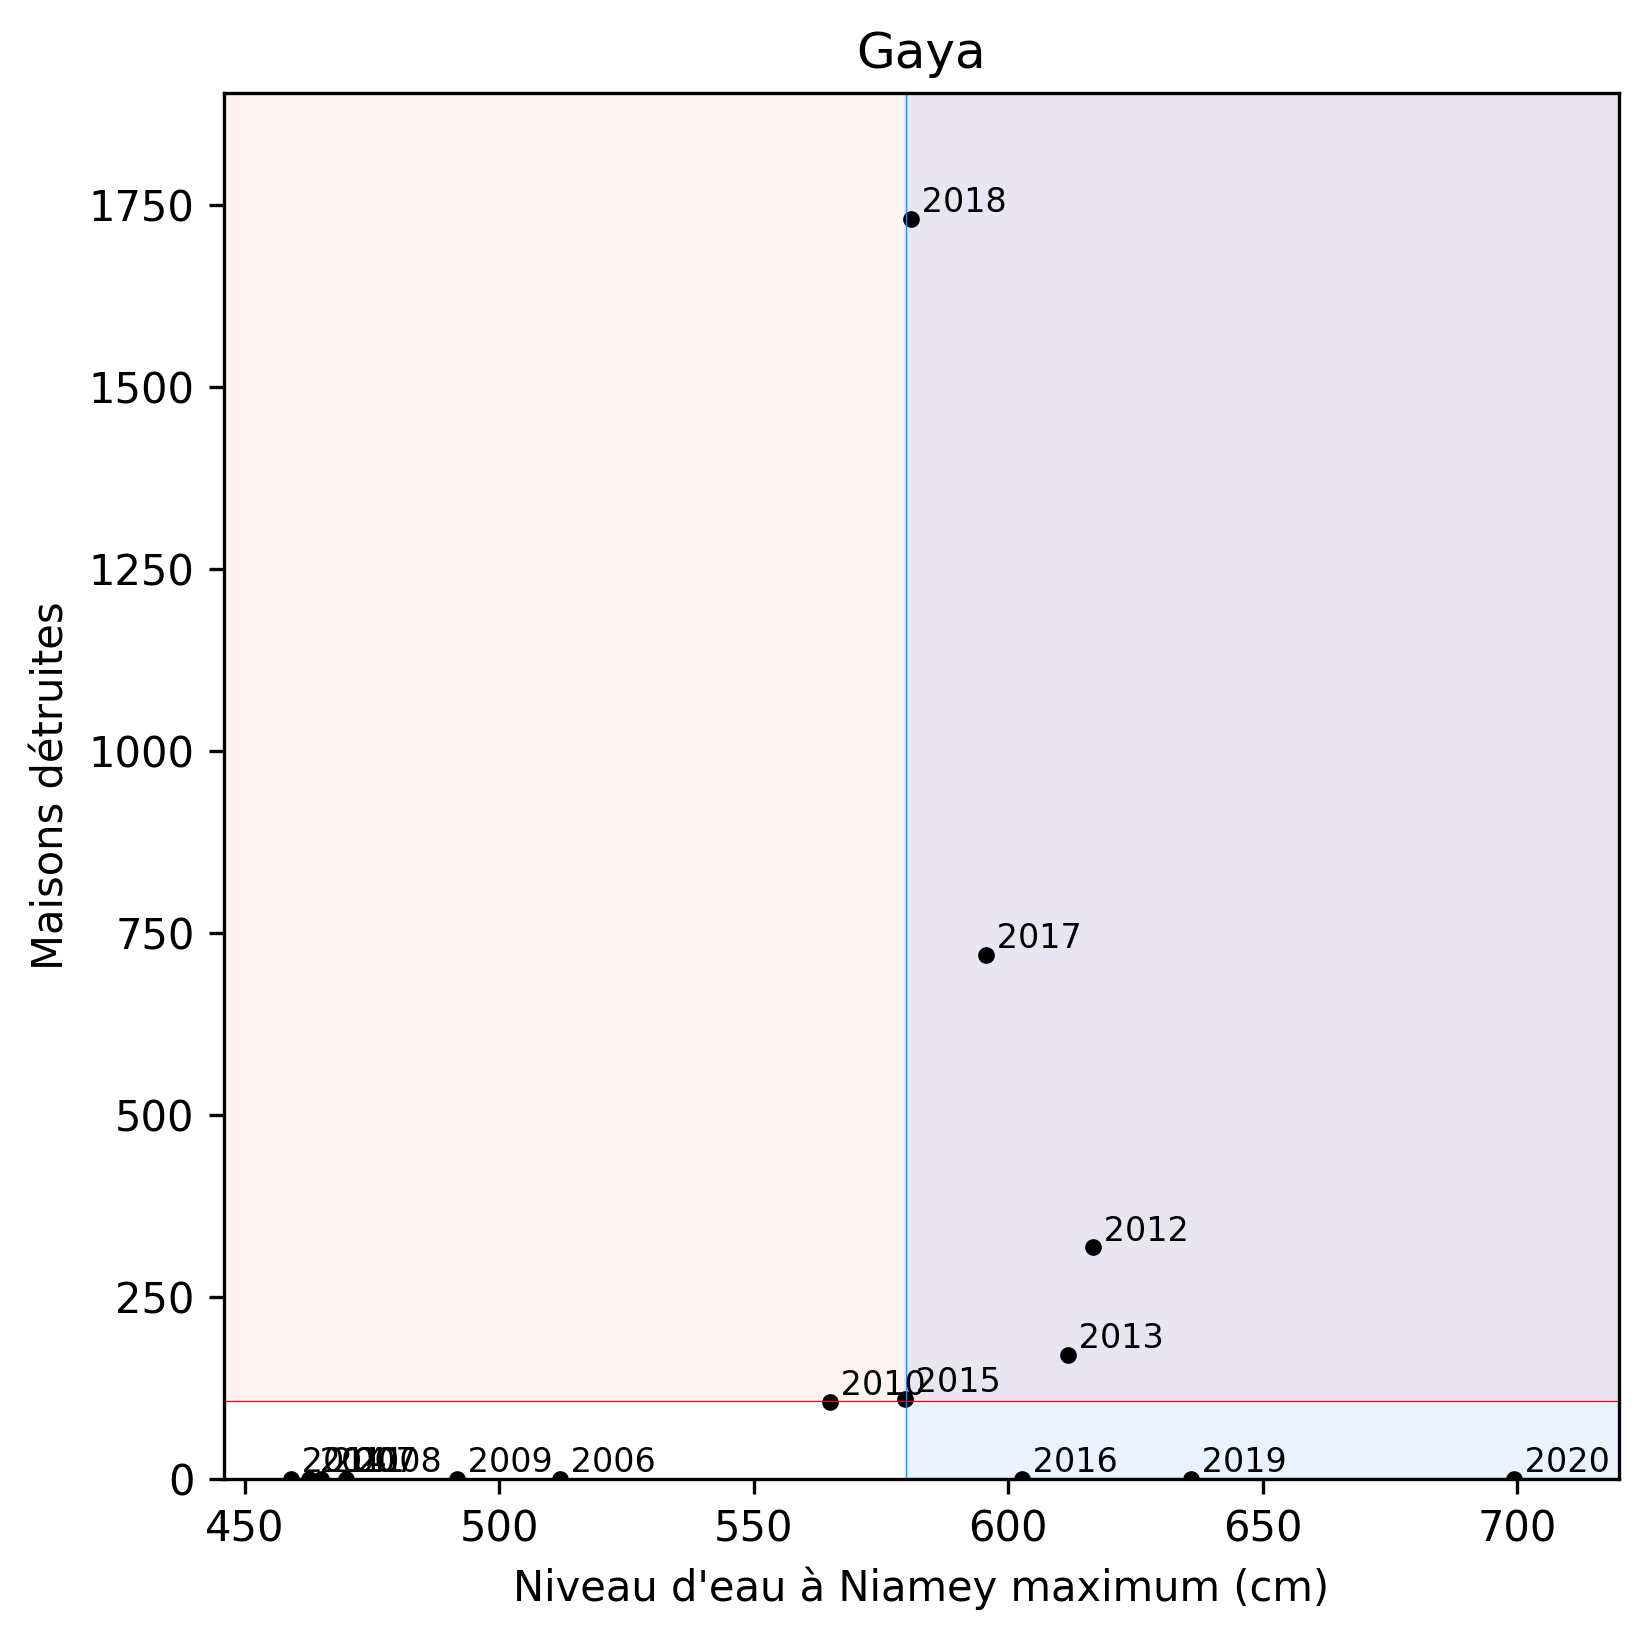

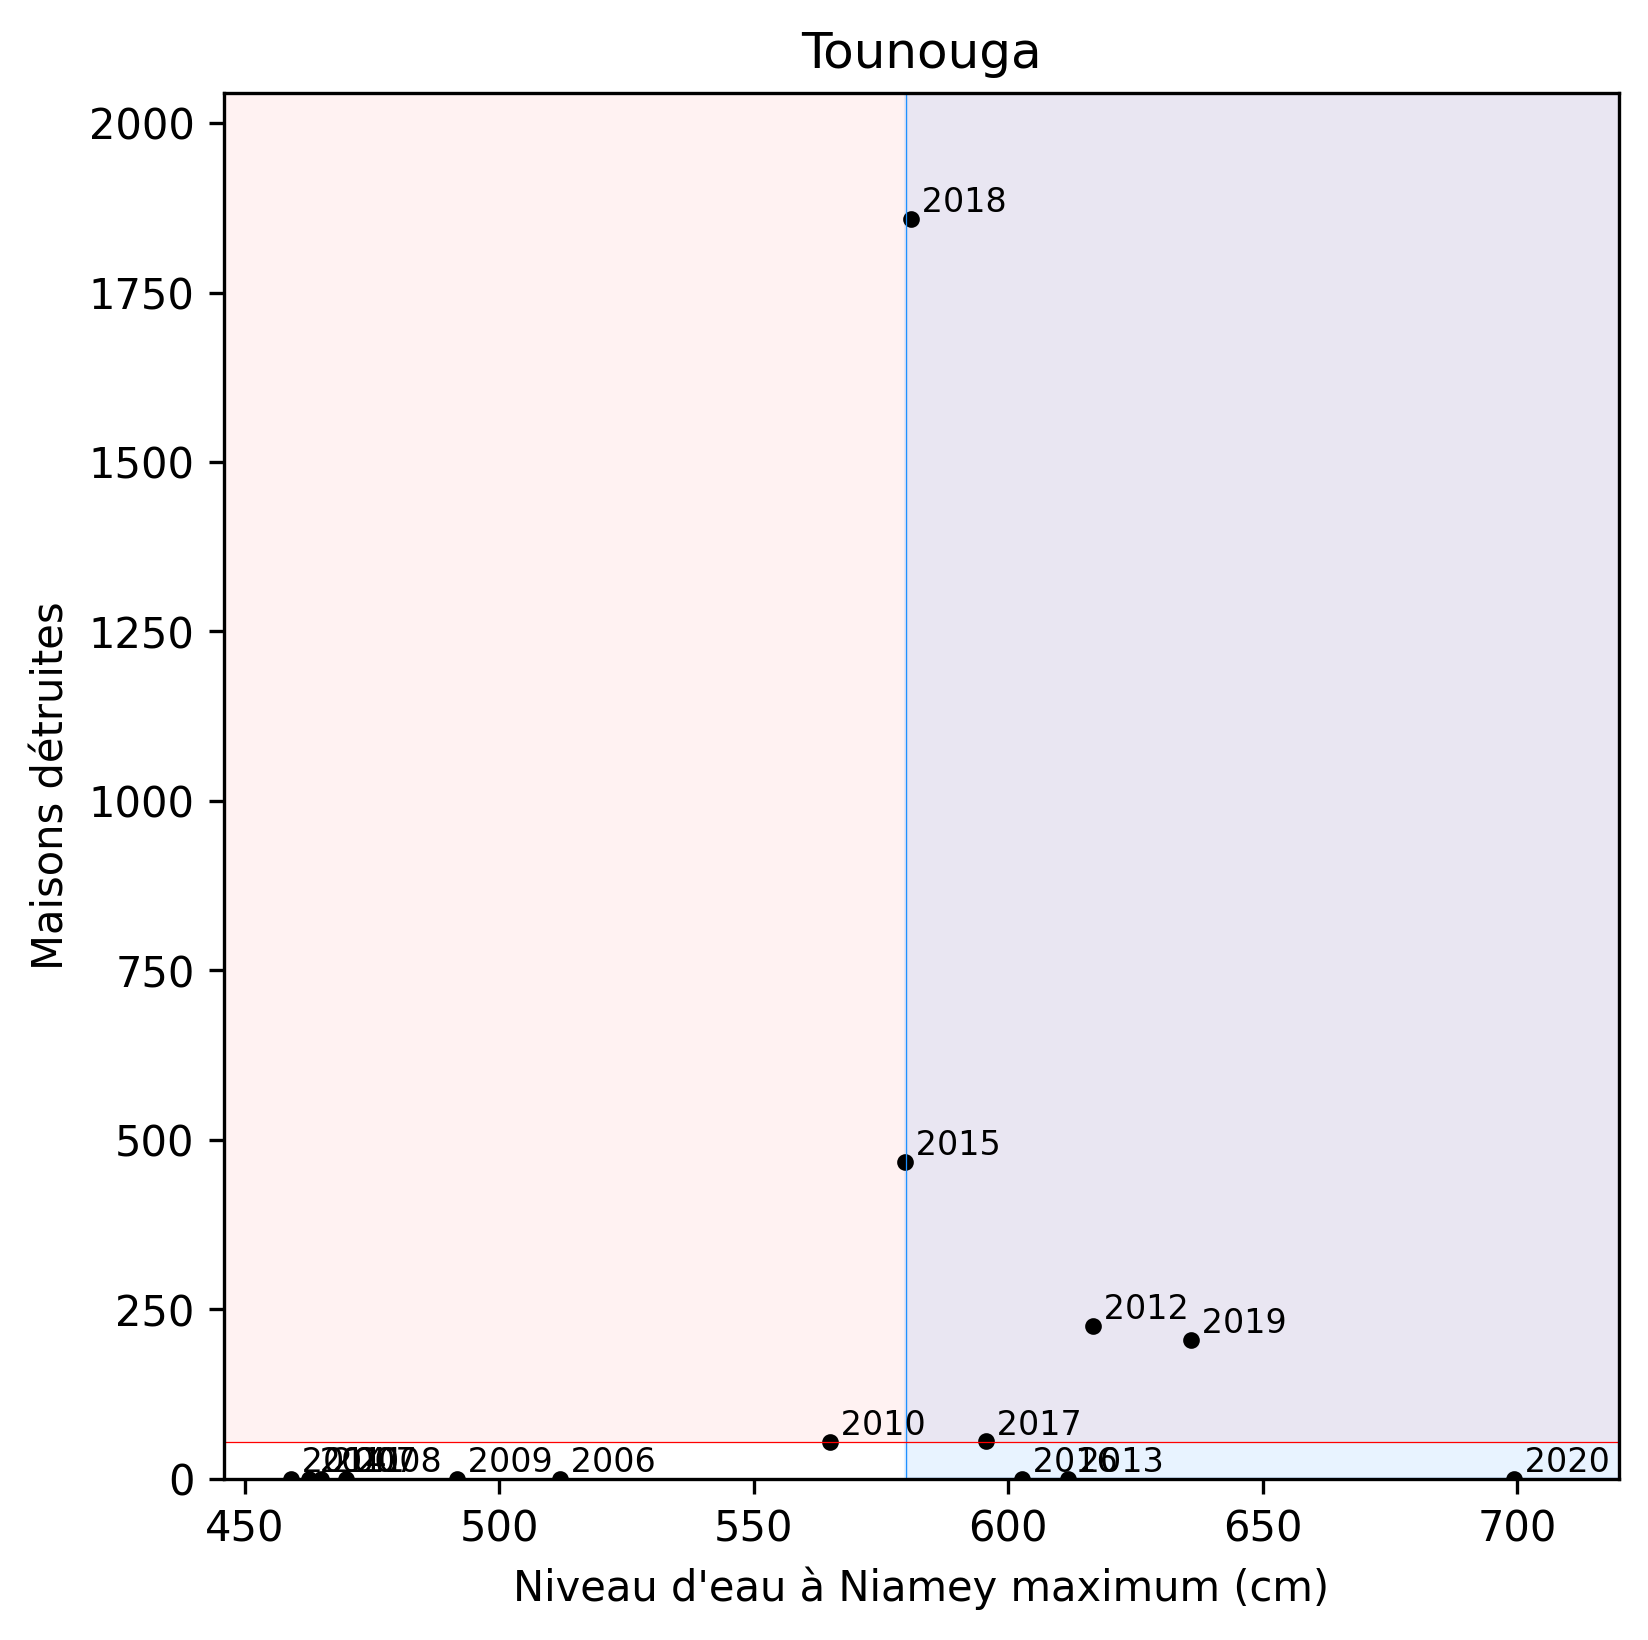

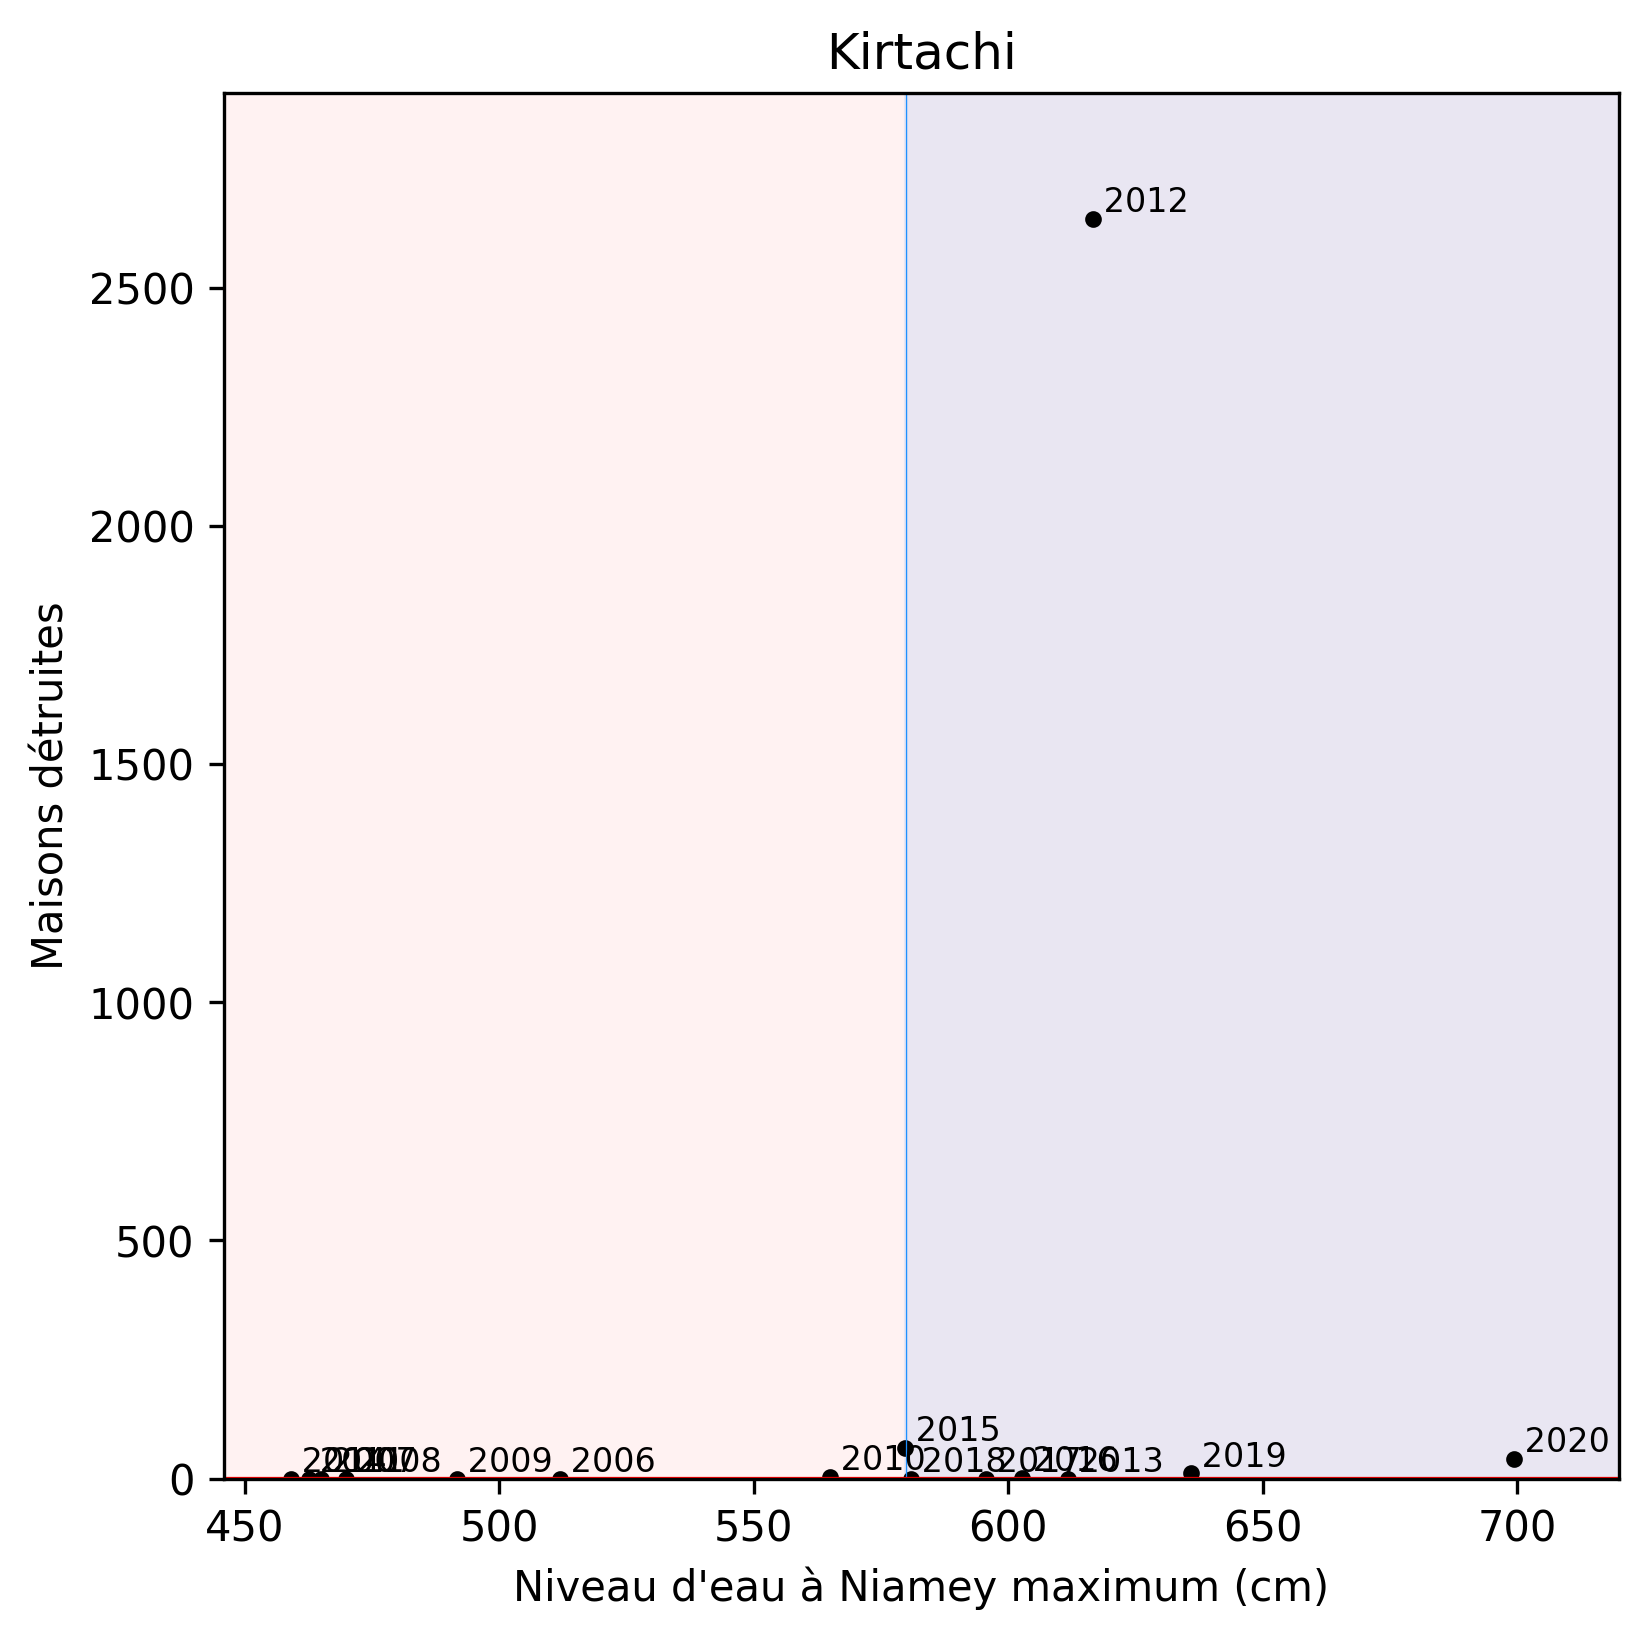

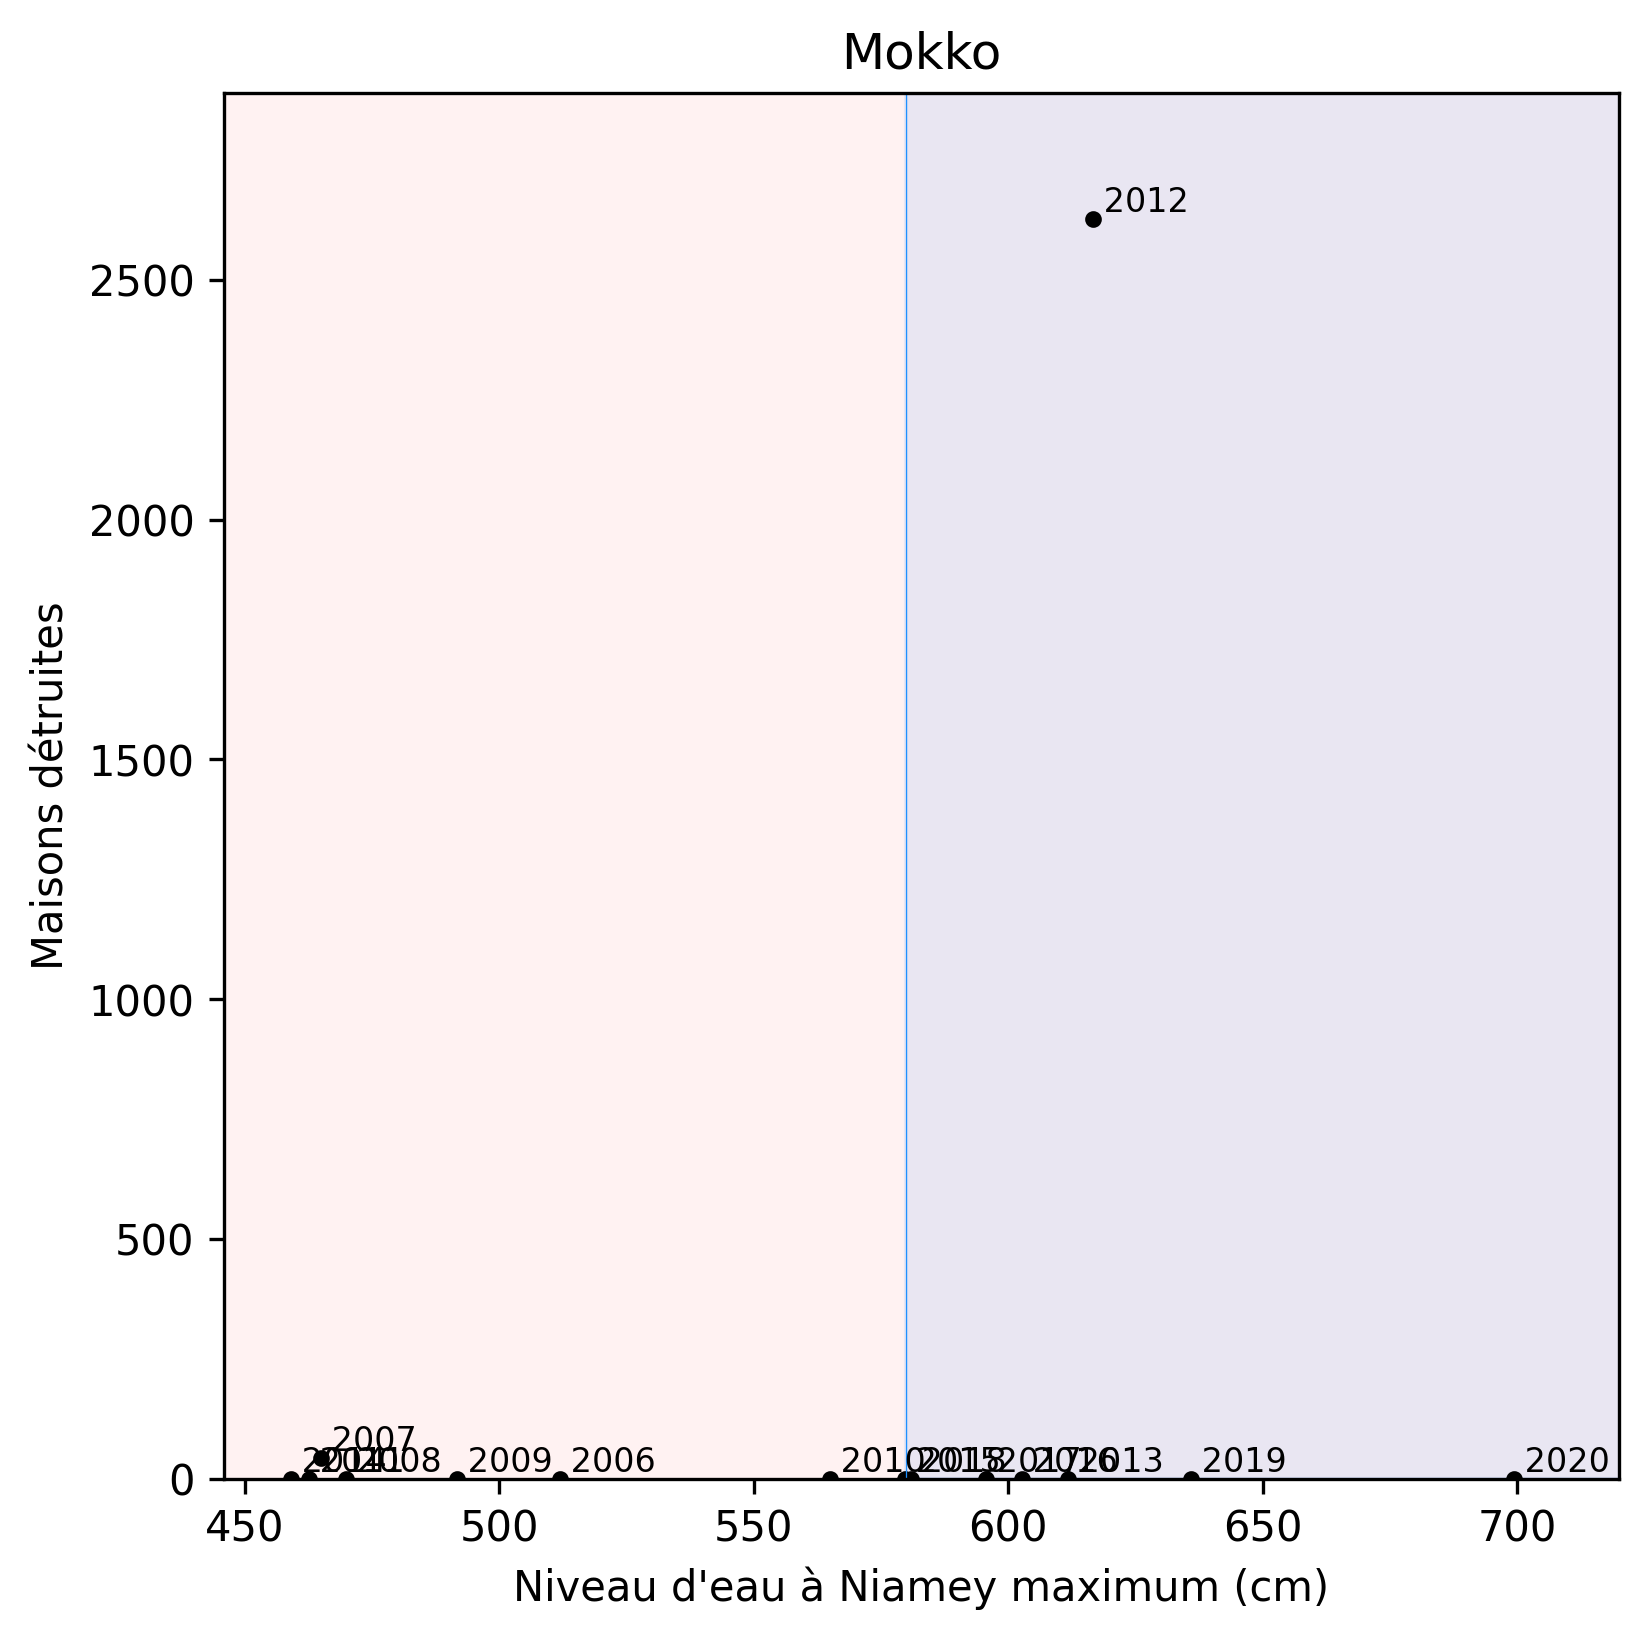

In [25]:
for pcode in all_corr["ADM3_PCODE"].iloc[:5]:
    name = adm3[adm3["ADM3_PCODE"] == pcode]["ADM3_FR"].iloc[0]
    fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
    compare_f = compare[compare["ADM3_PCODE"] == pcode]
    compare_f.plot(
        x="level",
        y="destroyed",
        ax=ax,
        marker=".",
        linestyle="",
        color="k",
        legend=False,
    )
    for idx, row in compare_f.iterrows():
        ax.annotate(
            f' {row["year"]}',
            (row["level"], row["destroyed"]),
            ha="left",
            va="bottom",
            fontsize=8,
        )

    level_t = 580
    ax.axvline(x=level_t, color="dodgerblue", linestyle="-", linewidth=0.3)
    ax.axvspan(
        level_t,
        720 + 1,
        ymin=0,
        ymax=1,
        color="dodgerblue",
        alpha=0.1,
    )

    q = compare_f["destroyed"].quantile(q=2 / 3)
    ax.axhline(y=q, color="red", linestyle="-", linewidth=0.3)
    ax.axhspan(
        q,
        compare_f["destroyed"].max() * 1.2,
        color="red",
        alpha=0.05,
        linestyle="None",
    )

    ax.set_xlabel("Niveau d'eau à Niamey maximum (cm)")
    ax.set_ylabel("Maisons détruites")
    ax.set_title(name)
    ax.set_ylim(bottom=0, top=compare_f["destroyed"].max() * 1.1)
    ax.set_xlim(right=720)
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

Text(0.5, 1.0, 'Moyenne de maisons détruites par inondations (2006-2020)')

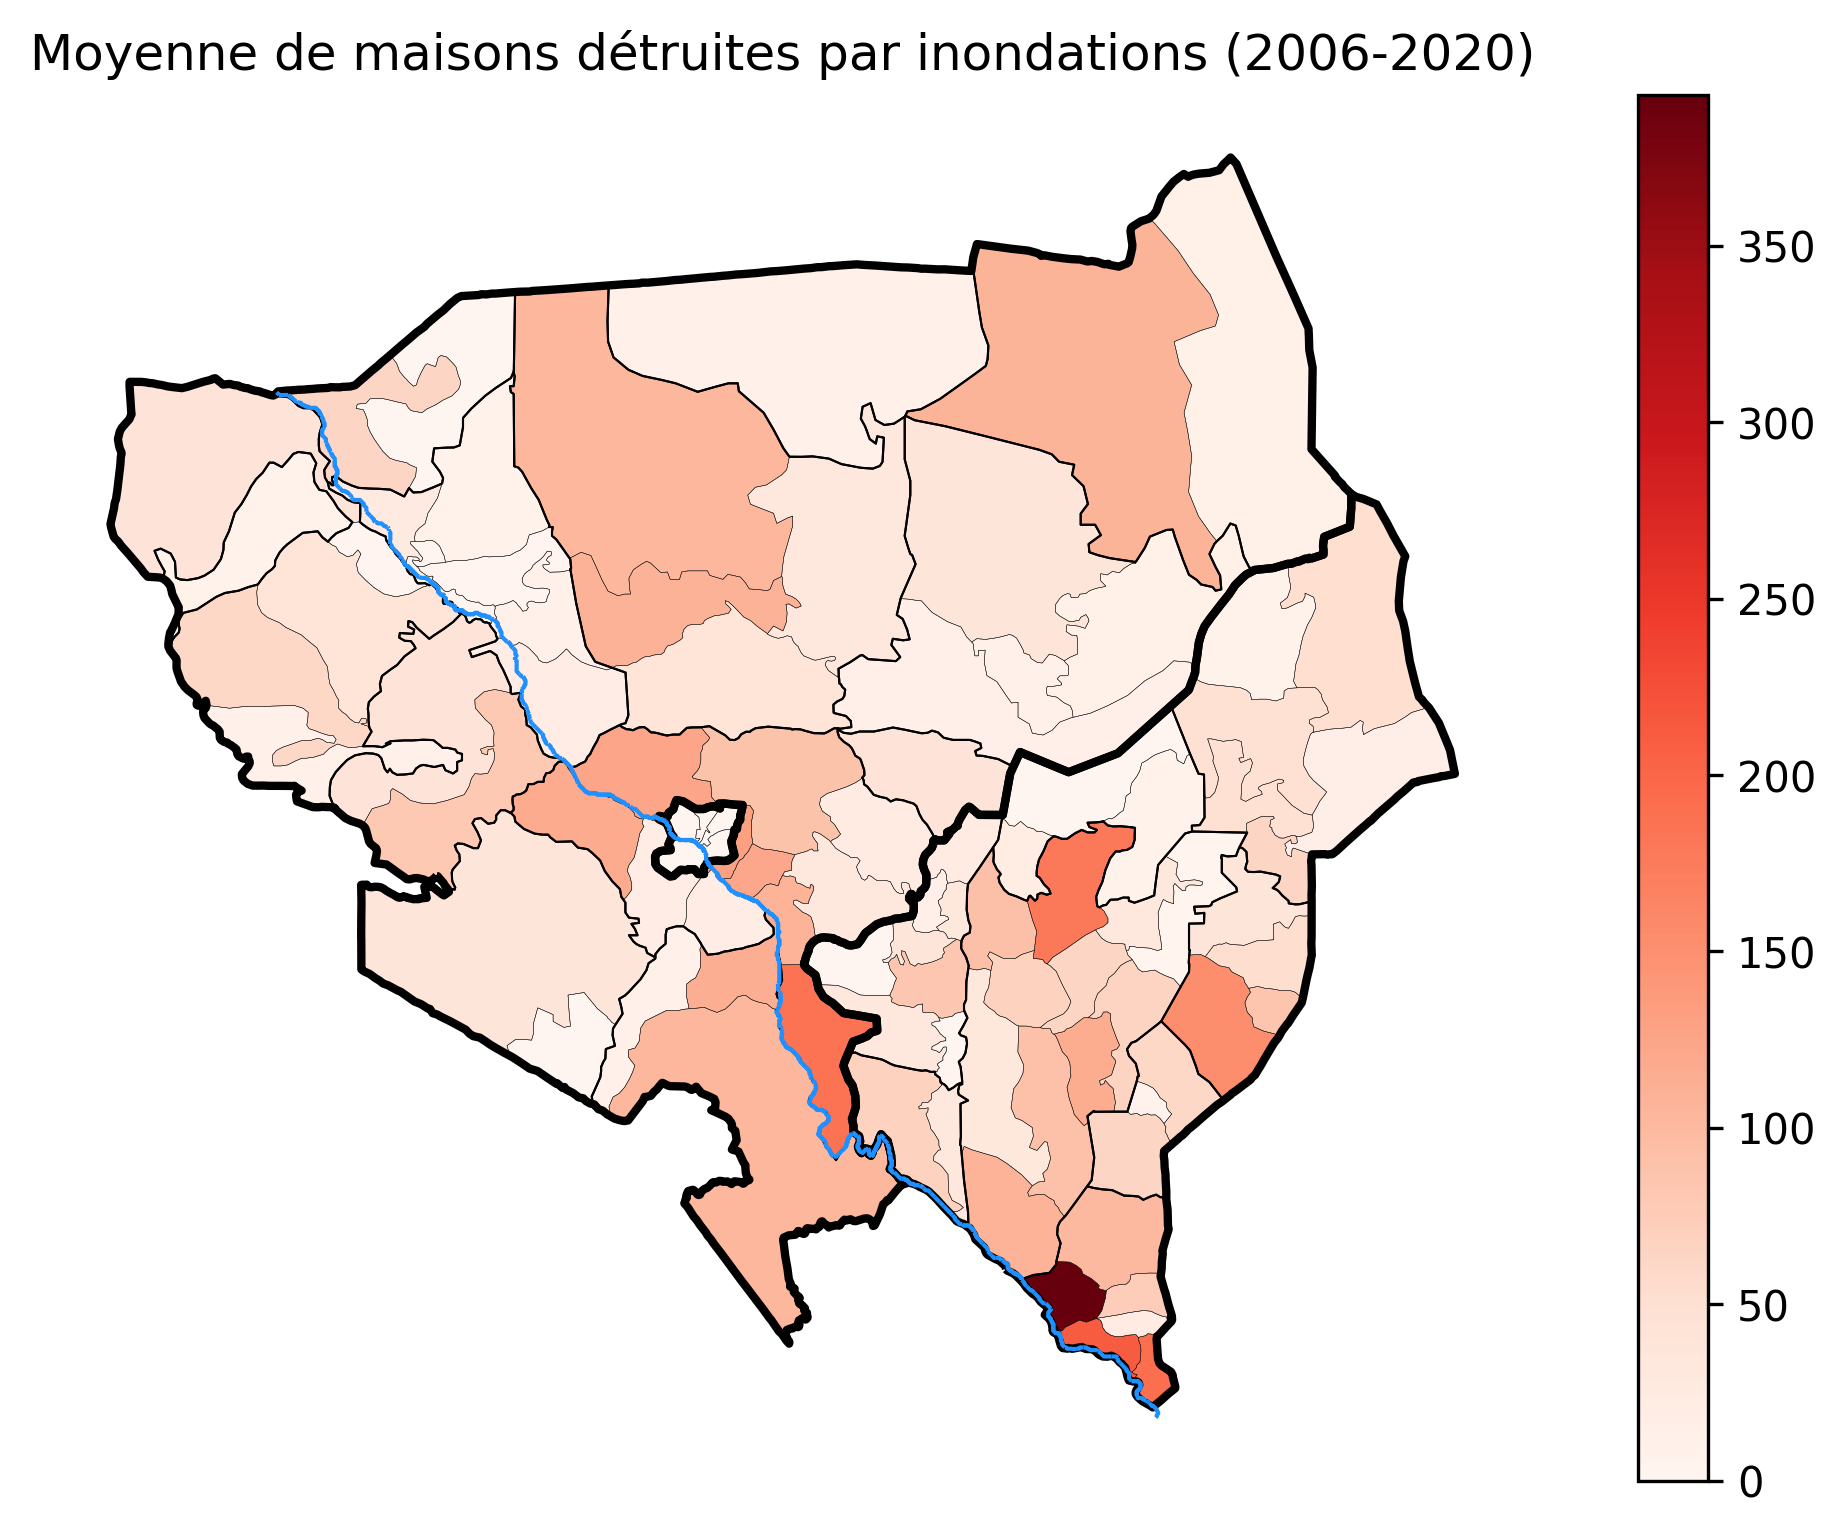

In [26]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax = adm3.merge(impact_sum_years_mean, on="ADM3_PCODE").plot(
    column="destroyed", cmap="Reds", ax=ax, legend=True
)
adm3.boundary.plot(ax=ax, color="k", linewidth=0.1)
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
adm1.boundary.plot(ax=ax, color="k", linewidth=2)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
ax.axis("off")
ax.set_title("Moyenne de maisons détruites par inondations (2006-2020)")

Text(0.5, 1.0, 'Taux de réussite de niveau du fleuve contre maisons détruites\n20 communes les plus touchées')

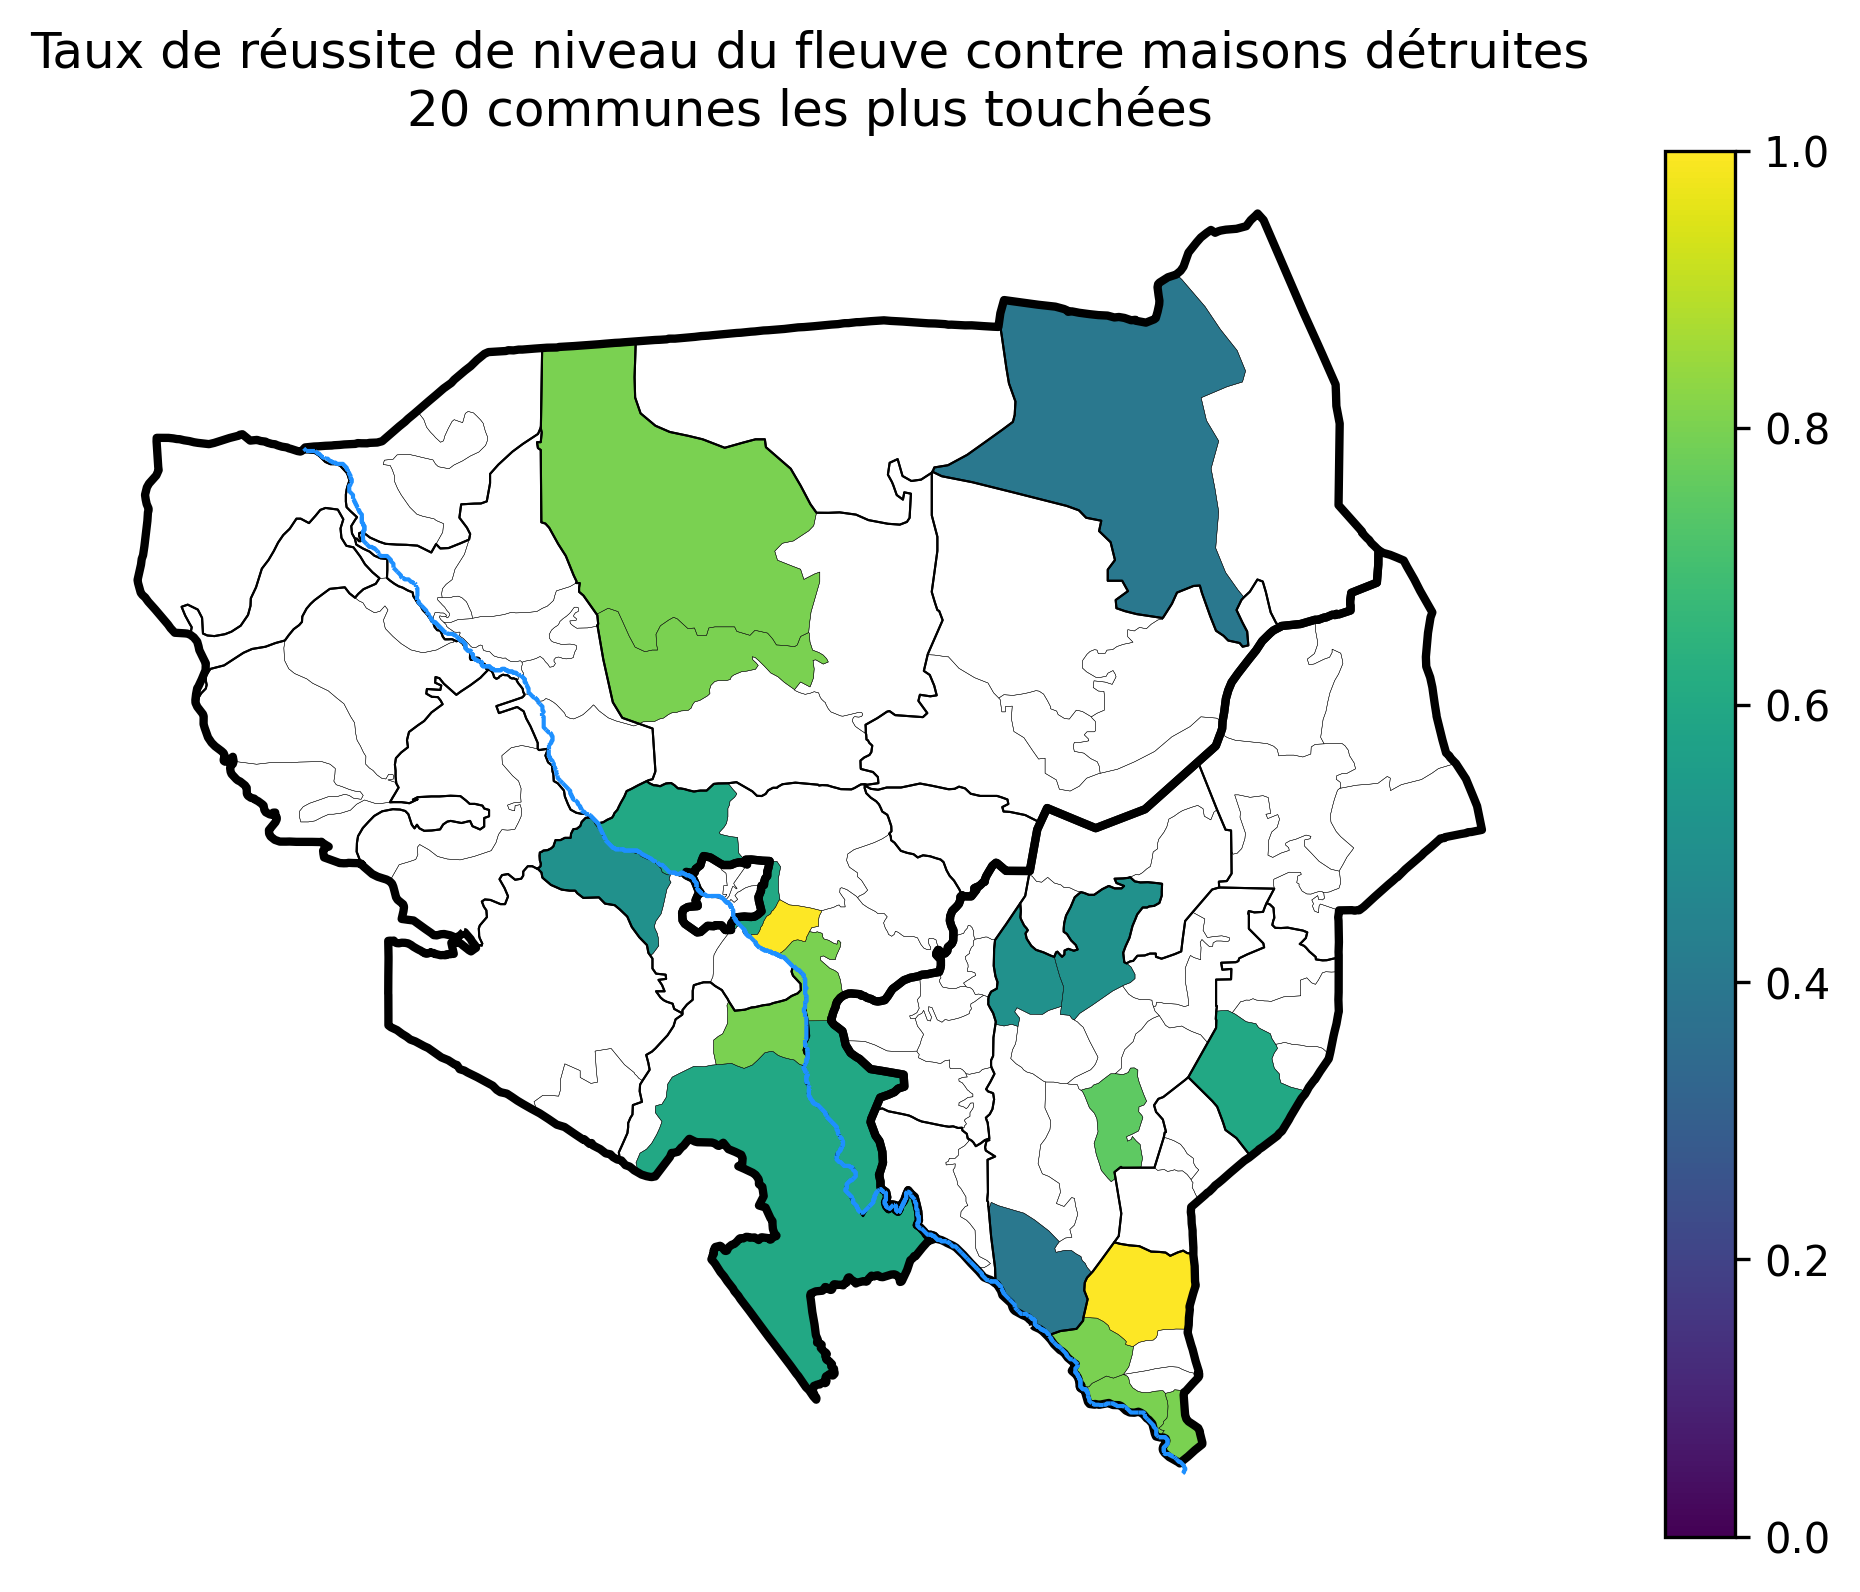

In [480]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
adm3.merge(all_corr.iloc[:20], on="ADM3_PCODE").plot(
    column="TPR", vmin=0, vmax=1, legend=True, ax=ax
)
adm3.boundary.plot(ax=ax, color="k", linewidth=0.1)
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
adm1.boundary.plot(ax=ax, color="k", linewidth=2)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
ax.axis("off")
ax.set_title(
    "Taux de réussite de niveau du fleuve contre maisons détruites\n"
    "20 communes les plus touchées"
)

In [34]:
df_save["Commune"].sort_values().unique()

array(['Abala', 'Anzourou', 'Ayerou', 'Bana', 'Banibangou', 'Bankilaré',
       'Bengou', 'Bibiyergou', "Birni N'Gaouré", 'Bitinkodji',
       'Dan-Kassari', 'Dargol', 'Dessa', 'Diagourou', 'Diantchandou',
       'Dingazi', 'Dioundiou', 'Dogondoutchi', 'Dogonkiria', 'Dosso',
       'Doumega', 'Fabidji', 'Falmey', 'Falwel', 'Farey', 'Filingué',
       'Garankédey', 'Gaya', 'Gollé', 'Goroubankassam', 'Gorouol',
       'Gothèye', 'Guilladjé', 'Guéchémé', 'Hamdallaye', 'Harikanassou',
       'Imanan', 'Kankandi', 'Karakara', 'Karguibangou', 'Karma', 'Kiota',
       'Kirtachi', 'Kiéché', 'Kokorou', 'Kollo', 'Koré Maïroua',
       'Kourfeye Centre', 'Kourteye', 'Kouré', 'Koygolo', 'Liboré',
       'Loga', 'Makalondi', 'Matankari', 'Mokko', 'Méhana', "N'Dounga",
       "N'Gonga", 'Namaro', 'Ouallam', 'Ouro Guéladjo', 'Sakoïra',
       'Sambéra', 'Sanam', 'Say', 'Simiri', 'Sokorbé', 'Soucoucoutane',
       'Tagazar', 'Tamou', 'Tanda', 'Tessa', 'Tibiri', 'Tillabéri',
       'Tombokoirey I', 'To

In [68]:
admin_names = {
    "ADM1_FR": "Région",
    "ADM2_FR": "Département",
    "ADM3_FR": "Commune",
}
var_names = {
    "TPR": "Taux de réussite (%)",
    "destroyed": "Maisons détruites",
    "fs_roll3": "Population exposée",
}

df_disp = (
    all_corr.merge(adm3[["ADM3_FR", "ADM3_PCODE", "ADM2_FR", "ADM1_FR"]])
    .sort_values("destroyed", ascending=False)
    .drop(columns=["ADM3_PCODE", "exp_corr", "level_corr"])
    .iloc[:20]
)
df_disp = df_disp[
    ["ADM1_FR", "ADM2_FR", "ADM3_FR", "destroyed", "fs_roll3", "TPR"]
]
df_disp["destroyed"] = df_disp["destroyed"].astype(int)
df_disp["TPR"] = df_disp["TPR"] * 100
int_cols = ["destroyed", "fs_roll3", "TPR"]
df_disp[int_cols] = df_disp[int_cols].astype(int)
df_disp = df_disp.rename(columns=admin_names | var_names)
df_disp.style.background_gradient(cmap="Blues")

,Région,Département,Commune,Maisons détruites,Population exposée,Taux de réussite (%)
0,Dosso,Gaya,Tanda,392,3509,80
1,Dosso,Gaya,Gaya,210,7087,80
2,Dosso,Gaya,Tounouga,191,3420,80
3,Tillabéri,Kollo,Kirtachi,184,795,60
4,Dosso,Dosso,Mokko,178,713,50
5,Dosso,Tibiri,Guéchémé,152,1037,60
6,Tillabéri,Kollo,Liboré,131,476,60
7,Tillabéri,Kollo,Karma,124,109,60
8,Tillabéri,Kollo,N'Dounga,122,130,100
9,Tillabéri,Kollo,Namaro,116,25,50


In [65]:
df_save = (
    all_corr.merge(adm3[["ADM3_FR", "ADM3_PCODE", "ADM2_FR", "ADM1_FR"]])
    .sort_values("destroyed", ascending=False)
    .drop(columns=["exp_corr", "level_corr"])
)
df_save = df_save[
    [
        "ADM3_PCODE",
        "ADM1_FR",
        "ADM2_FR",
        "ADM3_FR",
        "destroyed",
        "fs_roll3",
        "TPR",
    ]
]
df_save["destroyed"] = df_save["destroyed"].astype(int)
df_save["TPR"] = df_save["TPR"] * 100
# df_save = df_save.dropna()
int_cols = ["destroyed"]
df_save[int_cols] = df_save[int_cols].astype(int)
df_save = df_save.rename(columns=admin_names | var_names)

filename = "ner-ciblage-communes.xlsx"
df_save.to_excel(floodscan.PROC_FS_DIR / filename, index=False)

In [73]:
df_save[df_save["ADM3_PCODE"] == SINDER]

,ADM3_PCODE,Région,Département,Commune,Maisons détruites,Population exposée,Taux de réussite (%)
90,NE006012006,Tillabéri,Tillabéri,Sinder,0,4.133333,NaN


In [67]:
SINDER in df_save["ADM3_PCODE"].unique()

True

In [466]:
admin_names = {
    "ADM1_FR": "Région",
    "ADM2_FR": "Département",
    "ADM3_FR": "Commune",
}
var_names = {
    "TPR": "Taux de réussite (%)",
    "destroyed": "Maisons détruites",
    "fs_roll3": "Population exposée",
}

df_disp = (
    all_corr.merge(adm3[["ADM3_FR", "ADM3_PCODE", "ADM2_FR", "ADM1_FR"]])
    .sort_values("destroyed", ascending=False)
    .drop(columns=["ADM3_PCODE", "exp_corr", "level_corr"])
    .iloc[:20]
)
df_disp = df_disp[["ADM1_FR", "ADM2_FR", "ADM3_FR", "destroyed"]]
df_disp["destroyed"] = df_disp["destroyed"].astype(int)
int_cols = ["destroyed"]
df_disp[int_cols] = df_disp[int_cols].astype(int)
df_disp = df_disp.rename(columns=admin_names | var_names)
df_disp.style.background_gradient(cmap="Reds", vmin=0)

,Région,Département,Commune,Maisons détruites
0,Dosso,Gaya,Tanda,392
1,Dosso,Gaya,Gaya,210
2,Dosso,Gaya,Tounouga,191
3,Tillabéri,Kollo,Kirtachi,184
4,Dosso,Dosso,Mokko,178
5,Dosso,Tibiri,Guéchémé,152
6,Tillabéri,Kollo,Liboré,131
7,Tillabéri,Kollo,Karma,124
8,Tillabéri,Kollo,N'Dounga,122
9,Tillabéri,Kollo,Namaro,116


Text(0.5, 1.0, 'Moyenne de maisons détruites par inondations (2006-2020)')

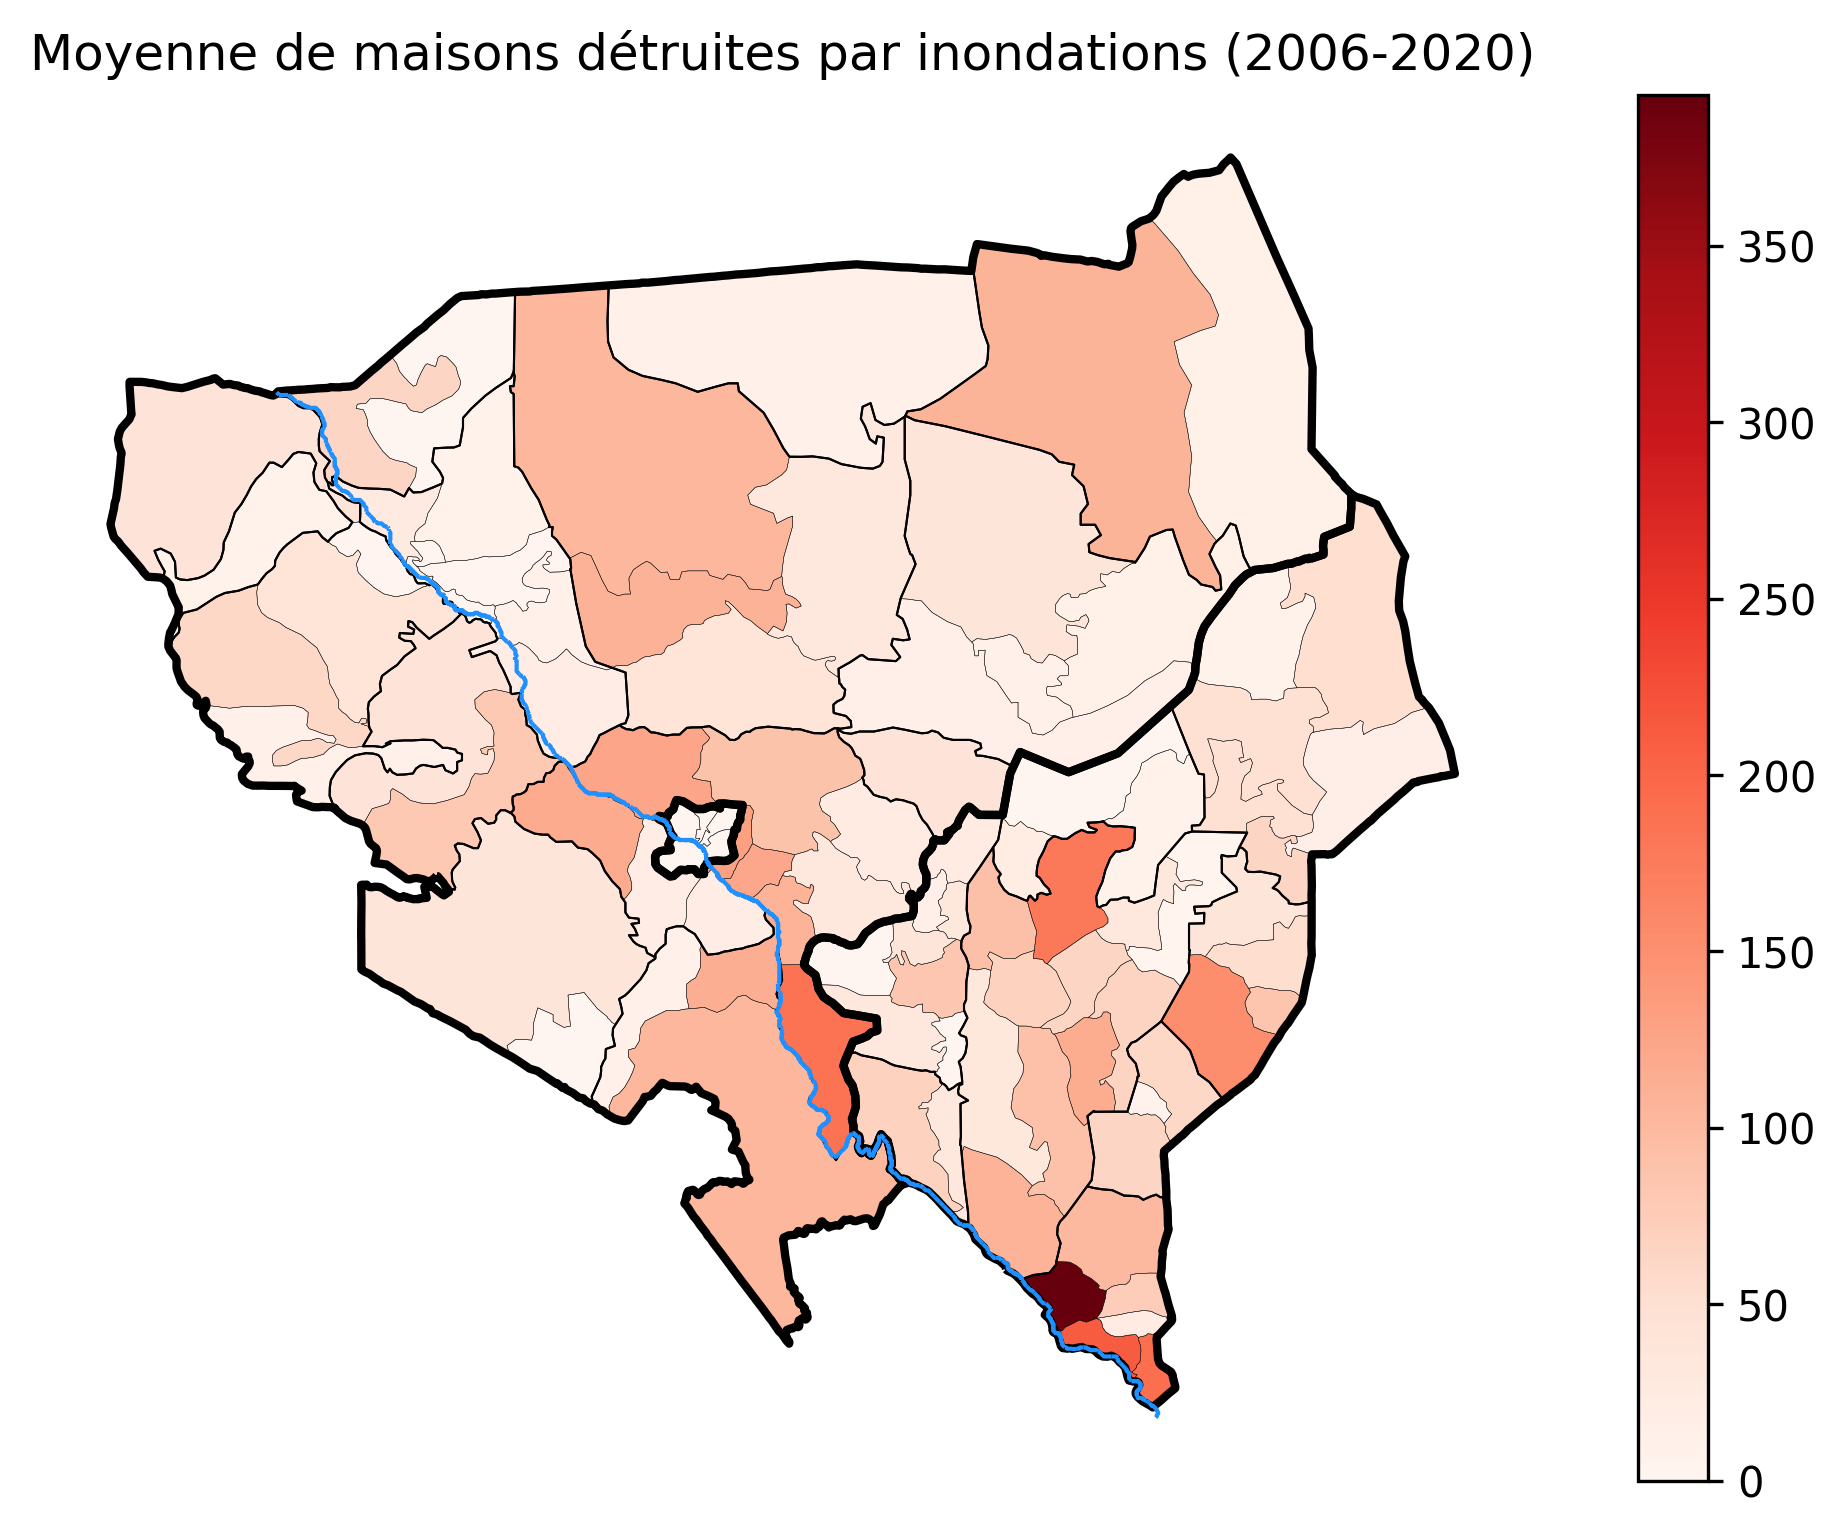

In [306]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
ax = adm3.merge(impact_sum_years_mean, on="ADM3_PCODE").plot(
    column="destroyed", cmap="Reds", ax=ax, legend=True
)
adm3.boundary.plot(ax=ax, color="k", linewidth=0.1)
adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
adm1.boundary.plot(ax=ax, color="k", linewidth=2)
river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
ax.axis("off")
ax.set_title("Moyenne de maisons détruites par inondations (2006-2020)")

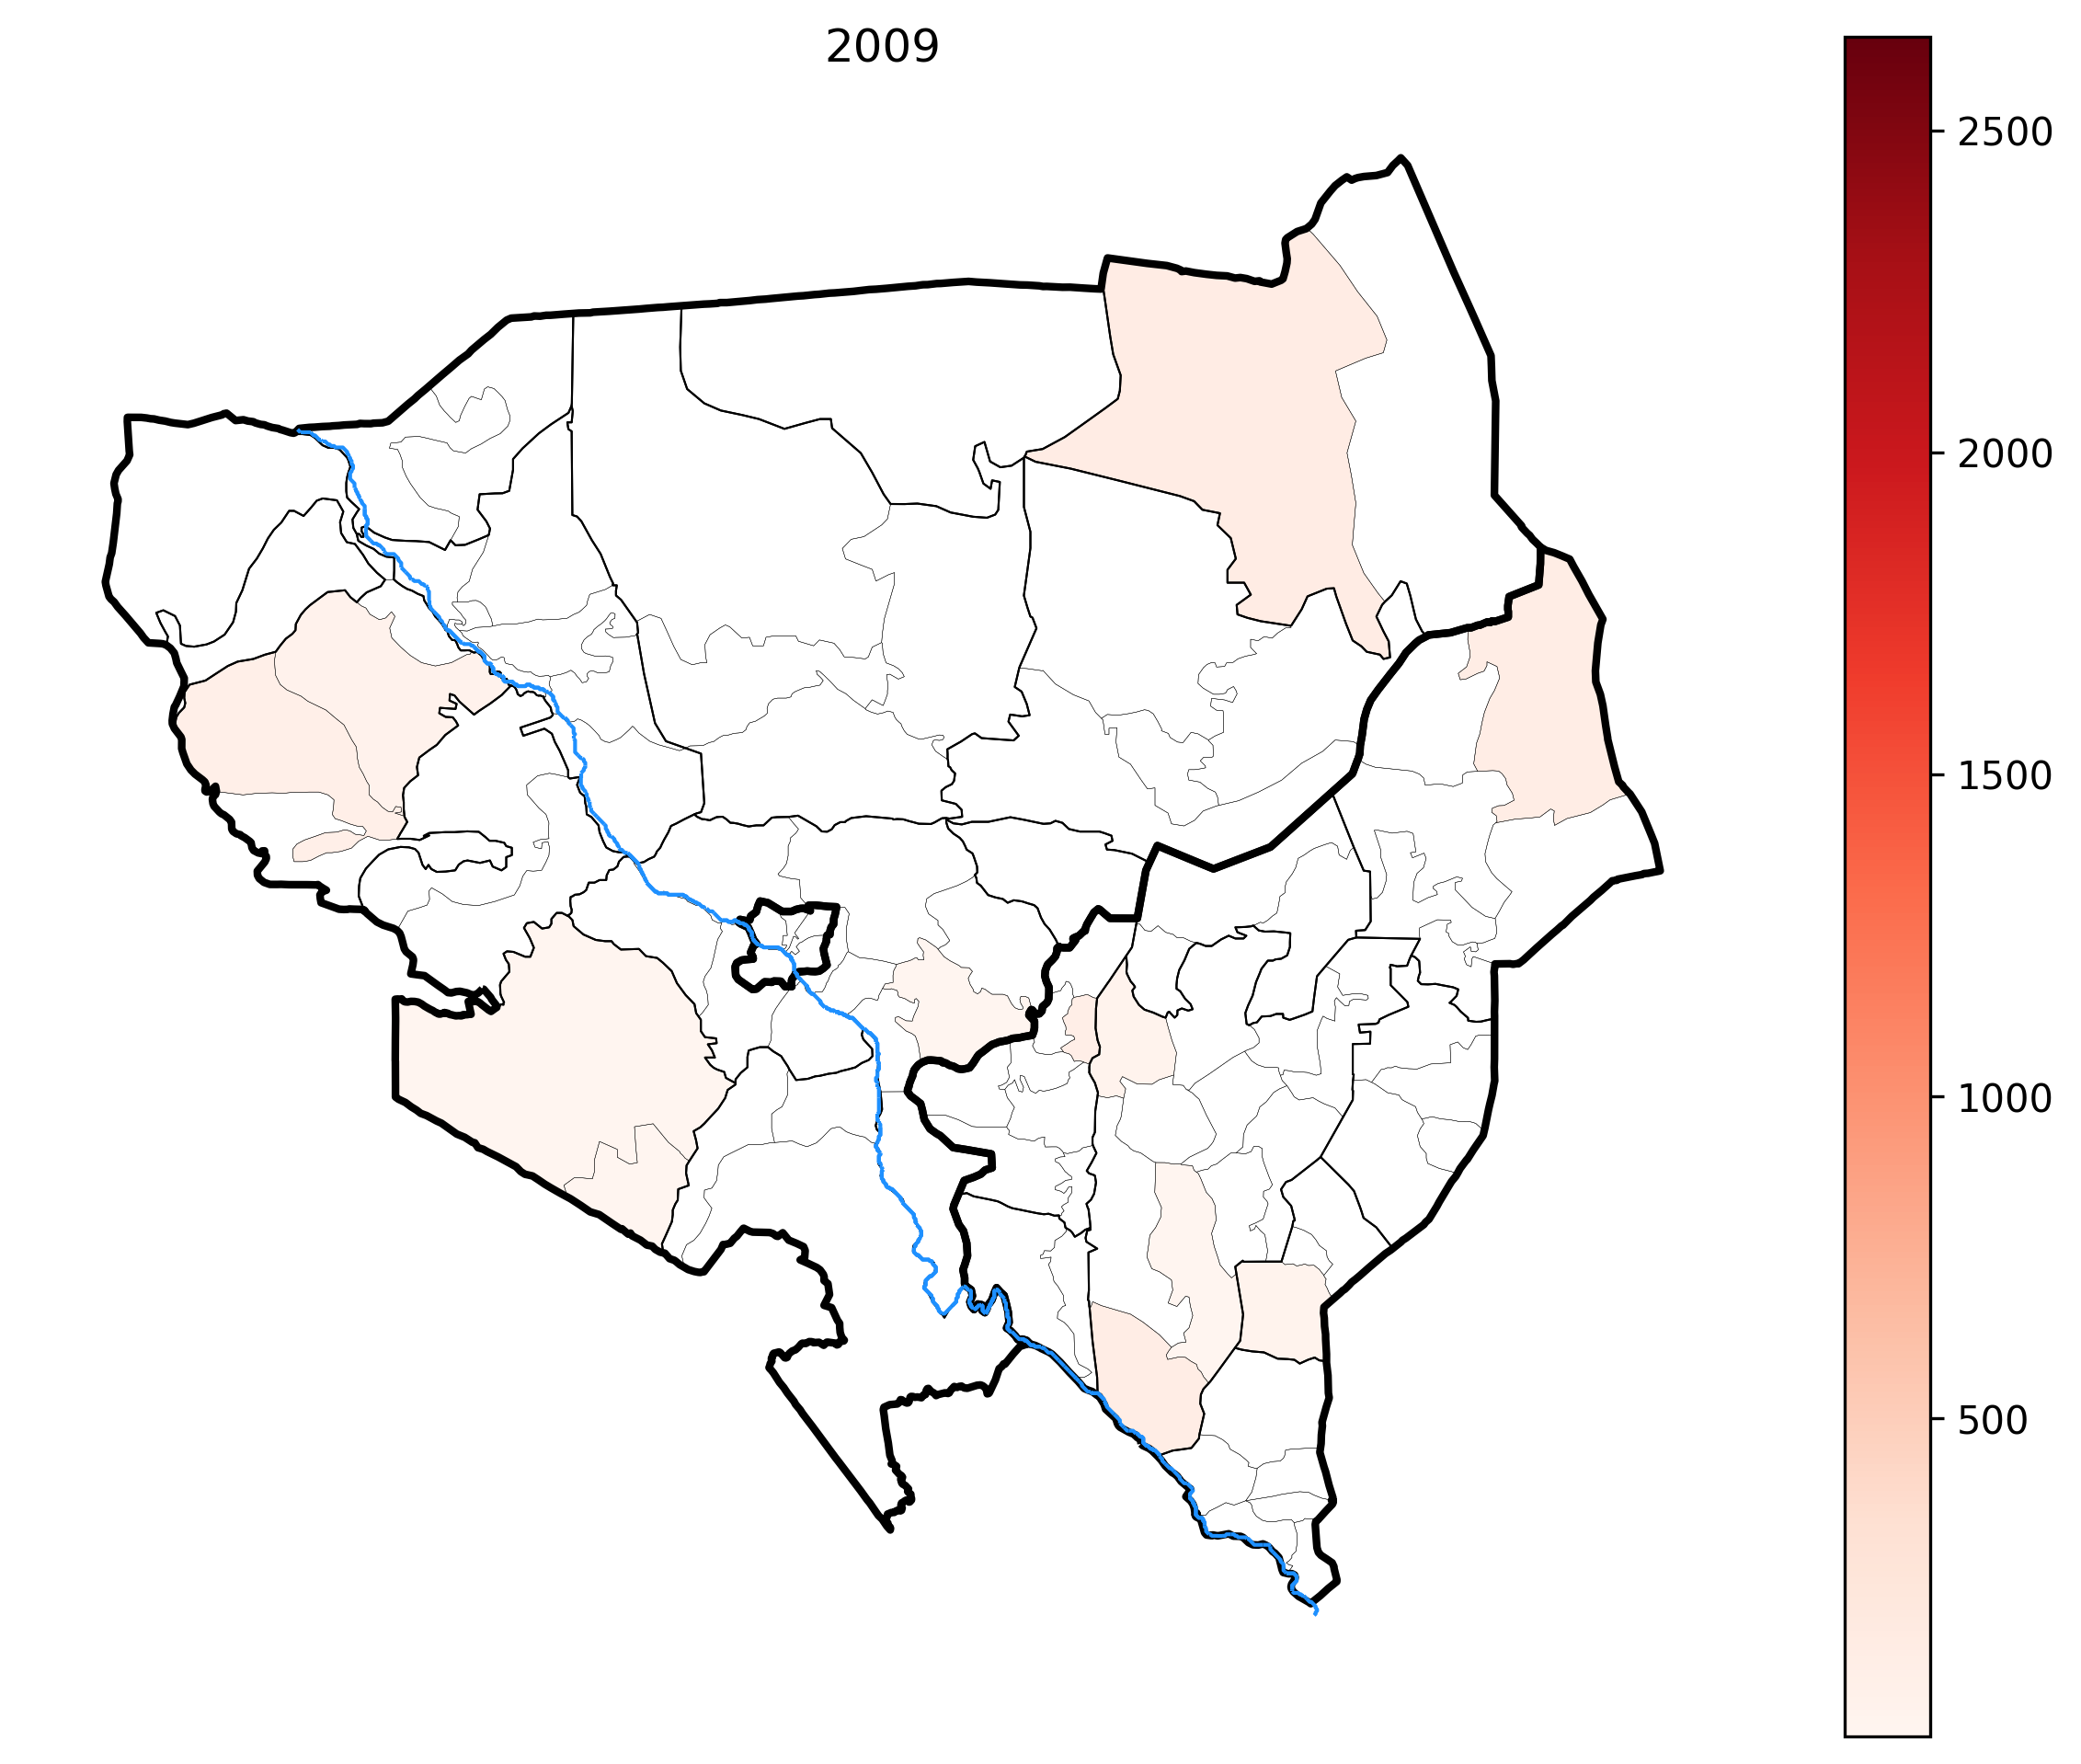

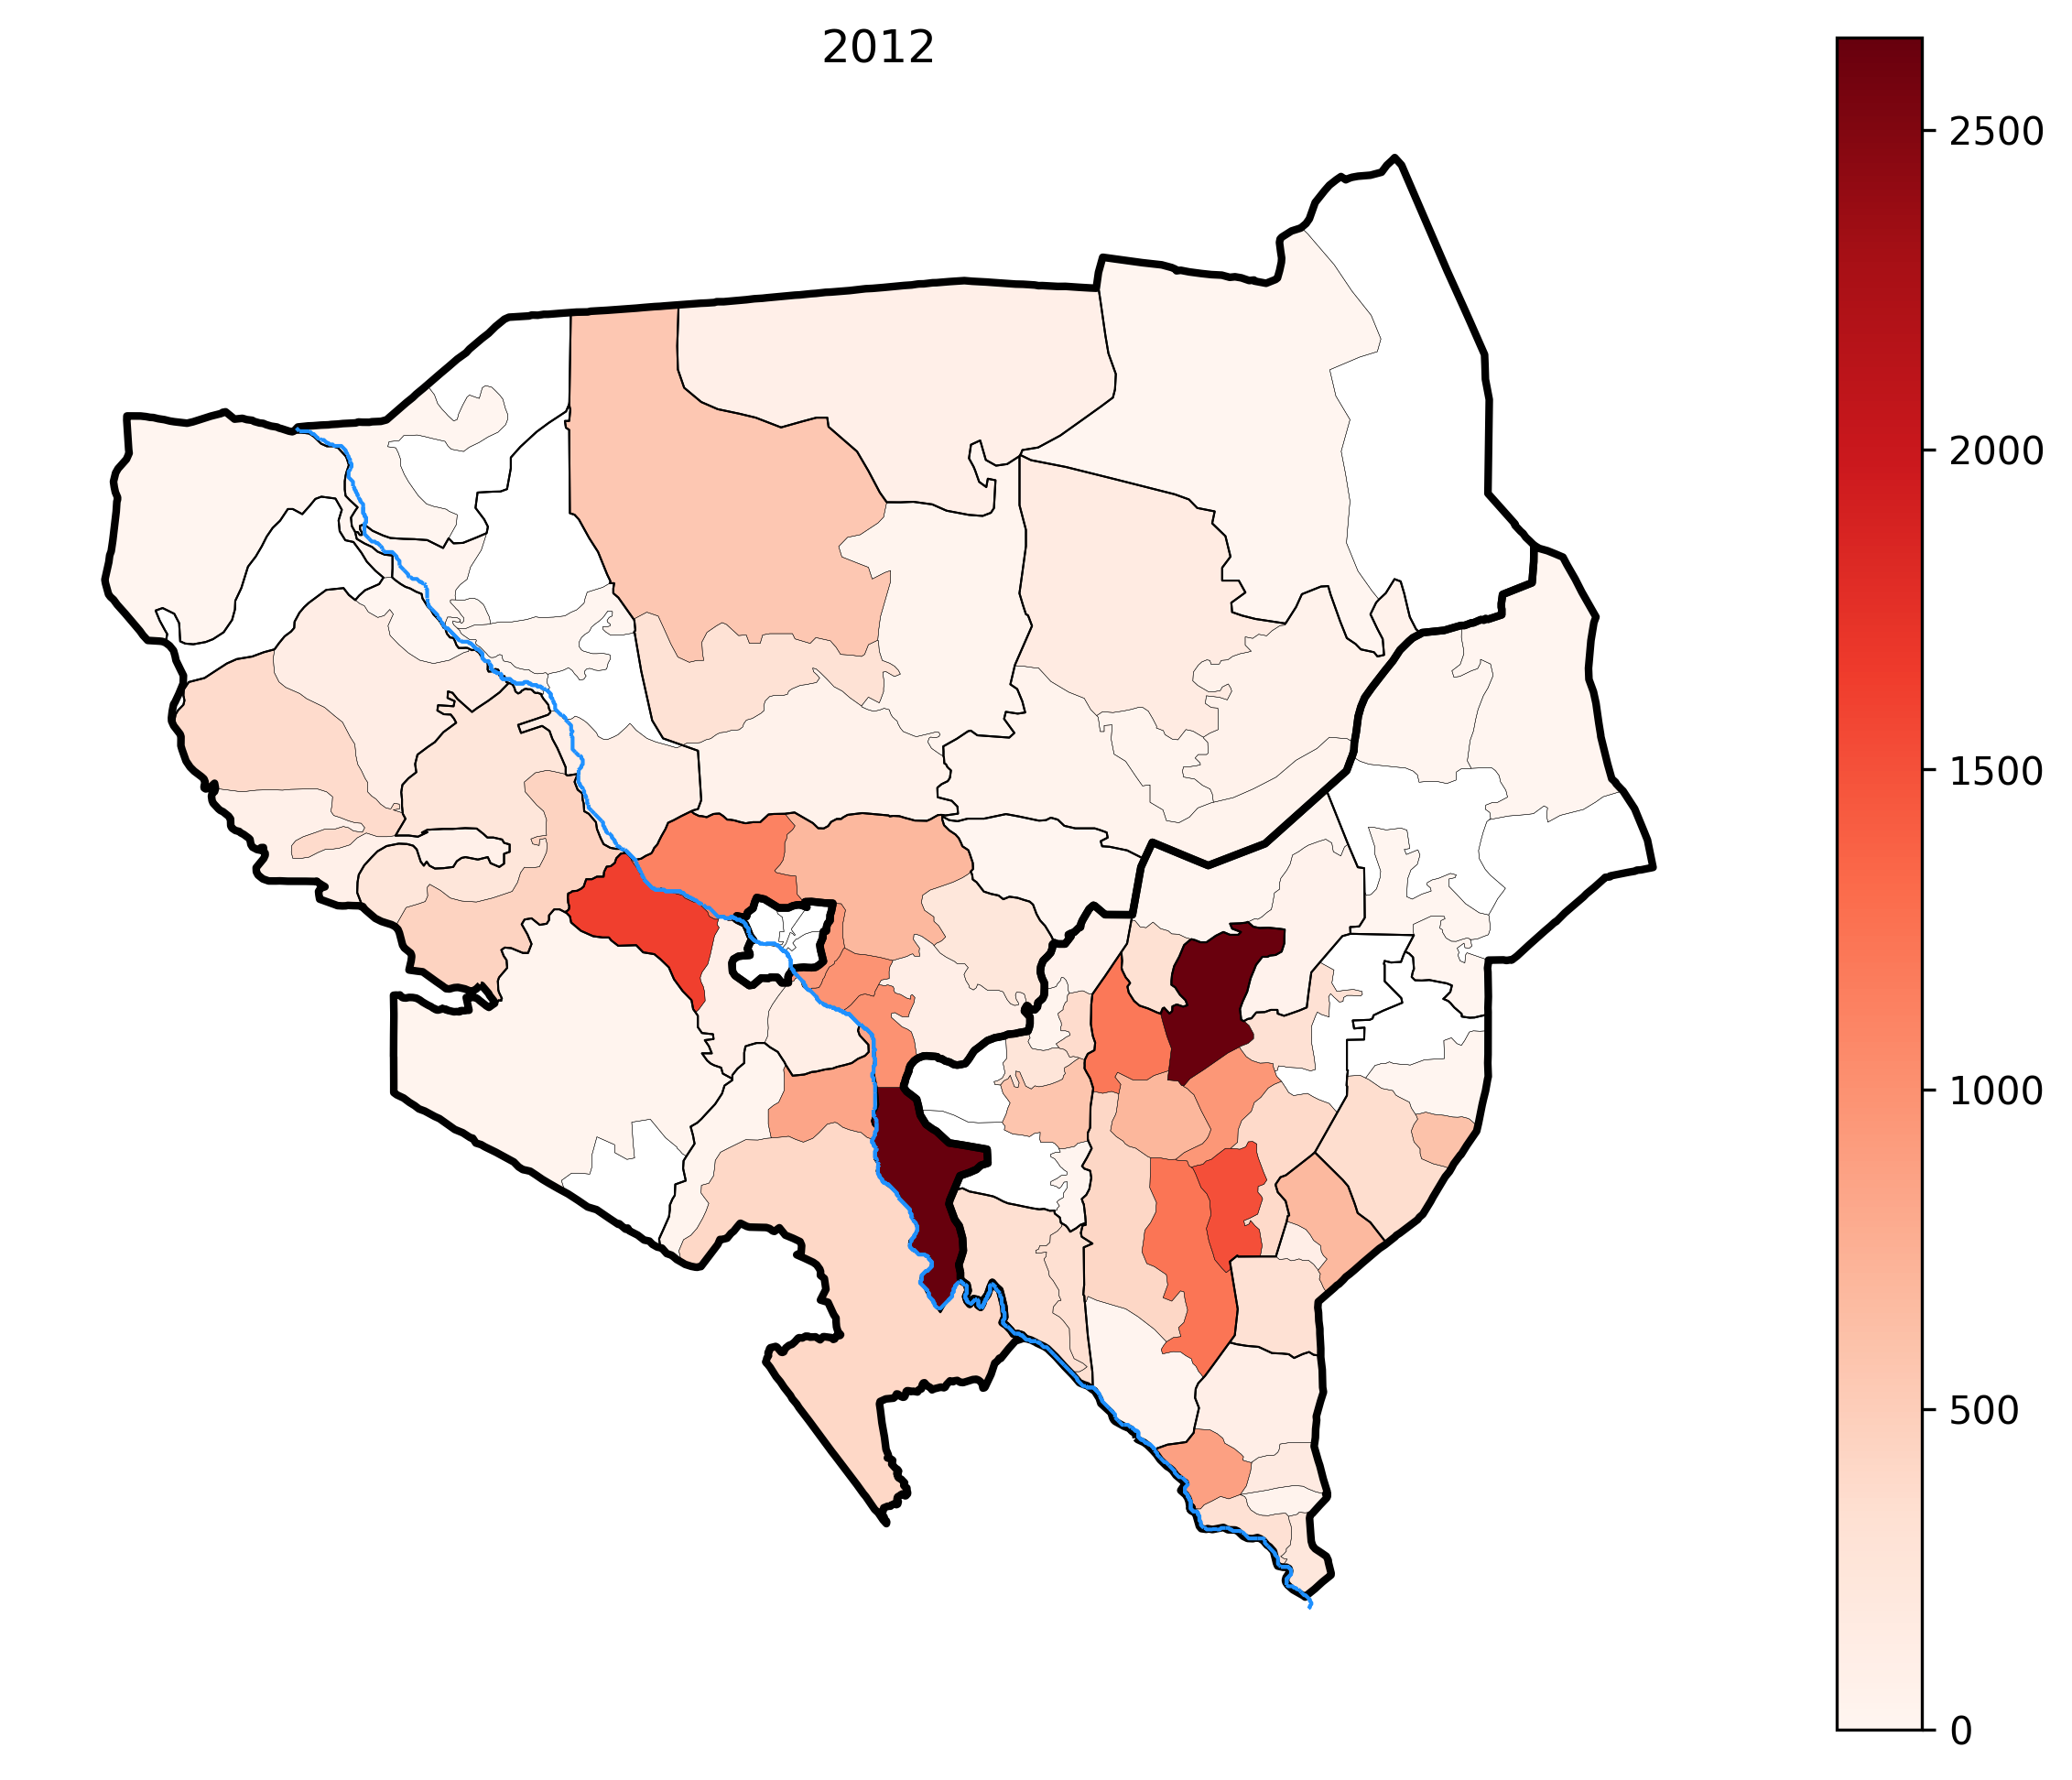

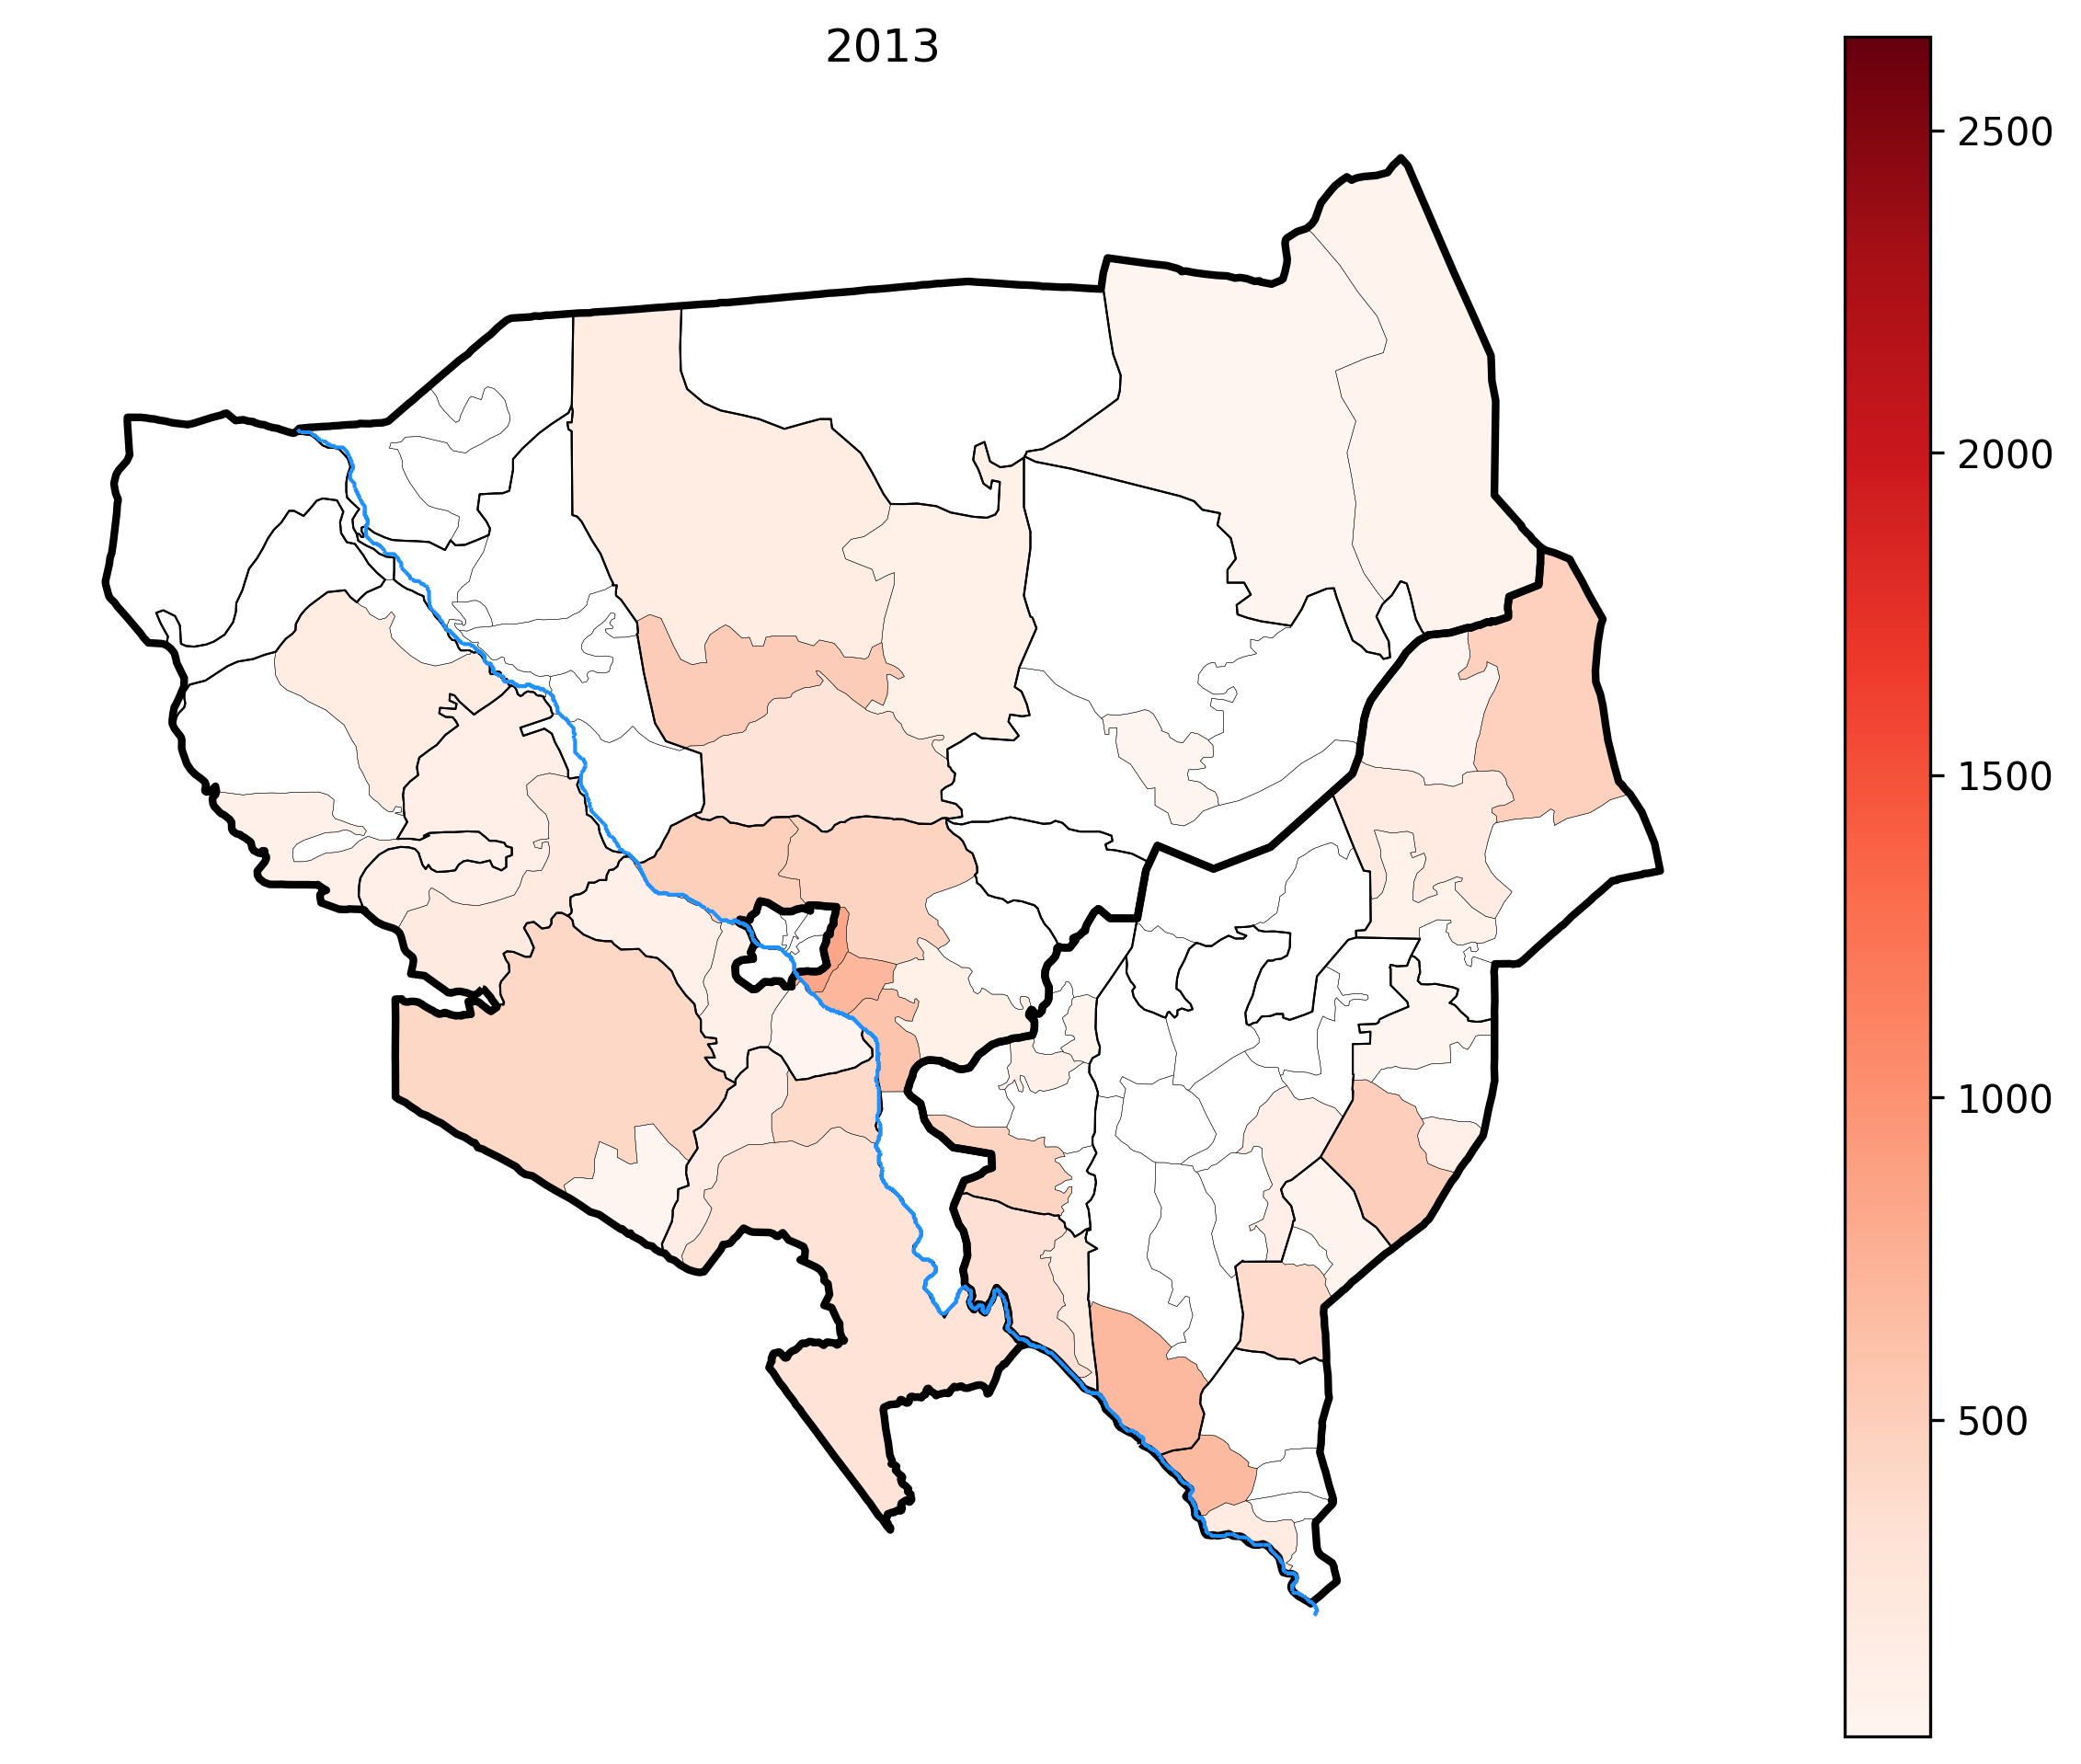

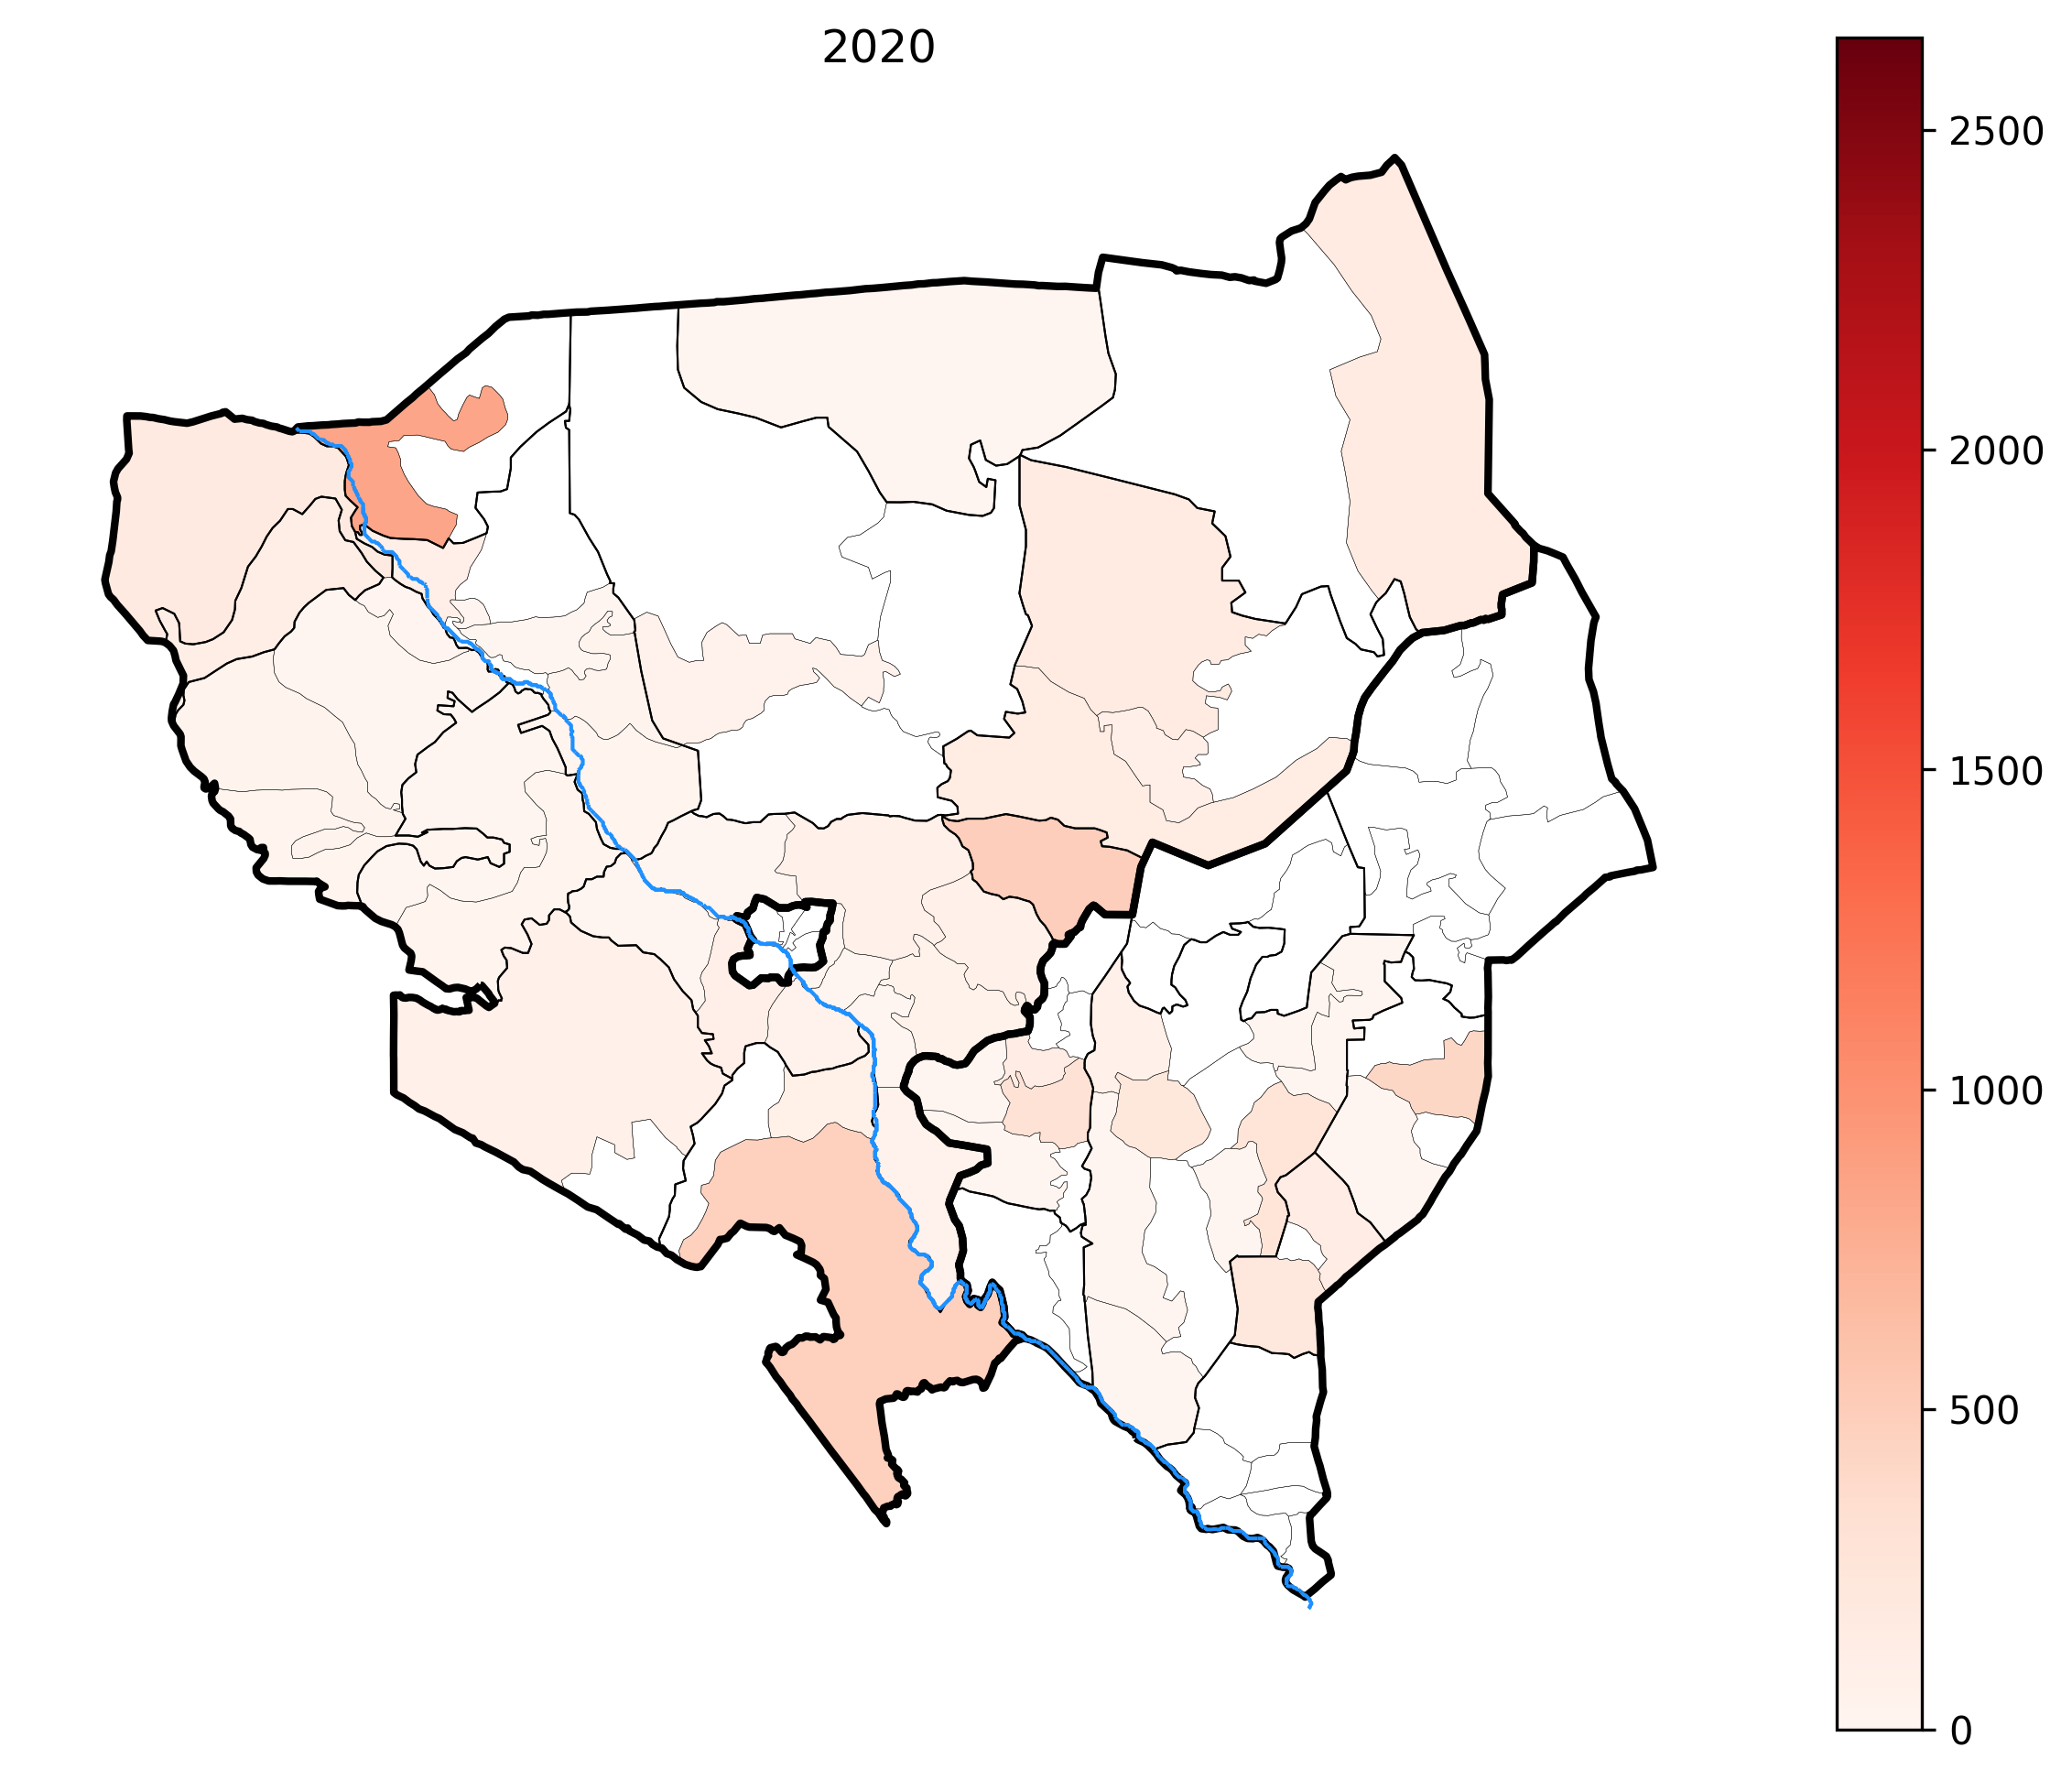

In [350]:
cerf_years = [2009, 2012, 2013, 2020]
vmax = impact_sum[impact_sum["year"].isin(cerf_years)]["destroyed"].max()

for year in cerf_years:
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    ax = adm3.merge(
        impact_sum.set_index("year").loc[year], on="ADM3_PCODE"
    ).plot(column="destroyed", cmap="Reds", ax=ax, legend=True, vmax=vmax)
    adm3.boundary.plot(ax=ax, color="k", linewidth=0.1)
    adm2.boundary.plot(ax=ax, color="k", linewidth=0.5)
    adm1.boundary.plot(ax=ax, color="k", linewidth=2)
    river_aoi.plot(ax=ax, color="dodgerblue", linewidth=1)
    ax.axis("off")
    ax.set_title(year)